In [9]:
import warnings
warnings.filterwarnings("ignore")

# 📊 Analisi della Mobilità Intelligente - Smart Mobility Traffic Analysis

## 🎯 Obiettivi del progetto

L'obiettivo di questo notebook è analizzare i dati di mobilità urbana per identificare condizioni del traffico, valutare la sicurezza stradale e costruire modelli predittivi legati alla congestione. L'analisi si basa sull'integrazione di più dataset contenenti informazioni su:

- Condizioni stradali e traffico (veicoli, incidenti, situazioni)
- Fattori che influenzano la sicurezza, come condizioni meteo e del manto stradale
- Elementi predittivi per valutare il rischio di incidenti

## 📁 Dataset utilizzati

1. `smart_mobility_dataset.csv`: contiene informazioni di base su traffico e mobilità

L’obiettivo finale sarà quello di costruire una base analitica utile per proposte di miglioramento della viabilità e sicurezza urbana.

In [10]:
#Importiamo le librerie 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

#Leggiamo il dataset
dataset = pd.read_csv('smart_mobility_dataset.csv')

dataset.head()


,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low


## 1 - Analisi Preliminare

In [3]:
#Visualizziamo i tipi delle colonne
print(f"{dataset.dtypes}\n")

print("Number of rows: ", dataset.shape[0])
print("Number of columns: ", dataset.shape[1])

Timestamp                  object
Latitude                  float64
Longitude                 float64
Vehicle_Count               int64
Traffic_Speed_kmh         float64
Road_Occupancy_%          float64
Traffic_Light_State        object
Weather_Condition          object
Accident_Report             int64
Sentiment_Score           float64
Ride_Sharing_Demand         int64
Parking_Availability        int64
Emission_Levels_g_km      float64
Energy_Consumption_L_h    float64
Traffic_Condition          object
dtype: object

Number of rows:  5000
Number of columns:  15


In [4]:
# calcolo statistiche descrittive
dataset.describe()

,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.749645,-73.847433,153.921200,42.111096,54.748397,0.096000,-0.005652,50.487800,24.613000,272.174927,17.343243
std,0.086123,0.086204,83.523342,21.707720,26.145238,0.294621,0.583790,28.484426,14.532511,130.086372,7.208277
min,40.600016,-73.999987,10.000000,5.002789,10.005031,0.000000,-0.999819,1.000000,0.000000,50.136855,5.003787
25%,40.675403,-73.920281,80.000000,23.195752,32.089653,0.000000,-0.500154,26.000000,12.000000,160.564433,11.098761
50%,40.748875,-73.846058,156.000000,42.191599,54.657297,0.000000,-0.010564,50.000000,24.000000,272.045513,17.153791
75%,40.824735,-73.771685,226.000000,60.751760,77.581720,0.000000,0.500518,75.000000,37.000000,382.242055,23.516595
max,40.899972,-73.700159,299.000000,79.997556,99.999729,1.000000,0.999354,99.000000,49.000000,499.922663,29.995416


In [5]:
#Verifica dati mancanti 
missing_values = dataset.isnull().sum()
print(missing_values)

Timestamp                 0
Latitude                  0
Longitude                 0
Vehicle_Count             0
Traffic_Speed_kmh         0
Road_Occupancy_%          0
Traffic_Light_State       0
Weather_Condition         0
Accident_Report           0
Sentiment_Score           0
Ride_Sharing_Demand       0
Parking_Availability      0
Emission_Levels_g_km      0
Energy_Consumption_L_h    0
Traffic_Condition         0
dtype: int64


### 📊 Istogrammi delle Feature Numeriche

In questa sezione analizziamo la distribuzione delle principali variabili numeriche del dataset.

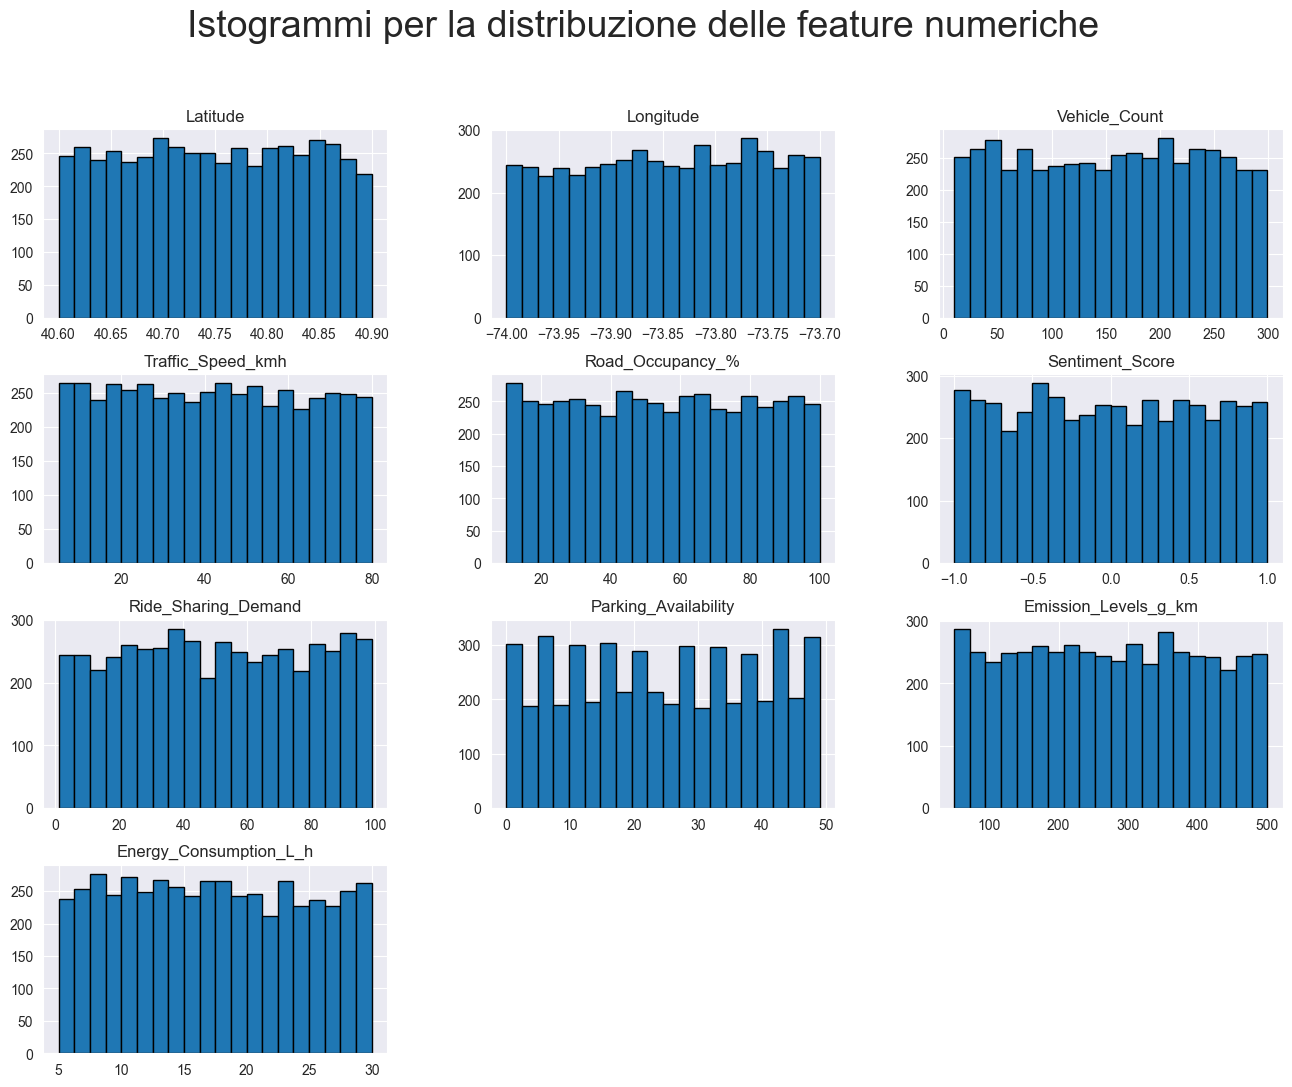

In [6]:
# Istogrammi per la distribuzione delle feature numeriche

# Elenco delle colonne da escludere
columns_to_exclude = ['Traffic_Light_State', 'Weather_Condition', 'Accident_Report' , 'Traffic_Condition']

# Creiamo il subset dei dati senza le feature da escludere
data_subset = dataset.drop(columns=columns_to_exclude)
data_subset.hist(bins=20, figsize=(16, 12), edgecolor='black')
plt.suptitle("Istogrammi per la distribuzione delle feature numeriche", fontsize=27)
plt.show()

### 📦 Box Plot delle Feature Numeriche

Questo grafico mostra i box plot di tutte le variabili numeriche del dataset. Il box plot è utile per:

- Osservare **mediana, quartili e intervallo interquartile (IQR)**
- Identificare **outlier** (valori anomali fuori dai baffi)
- Valutare **asimmetrie** nelle distribuzioni

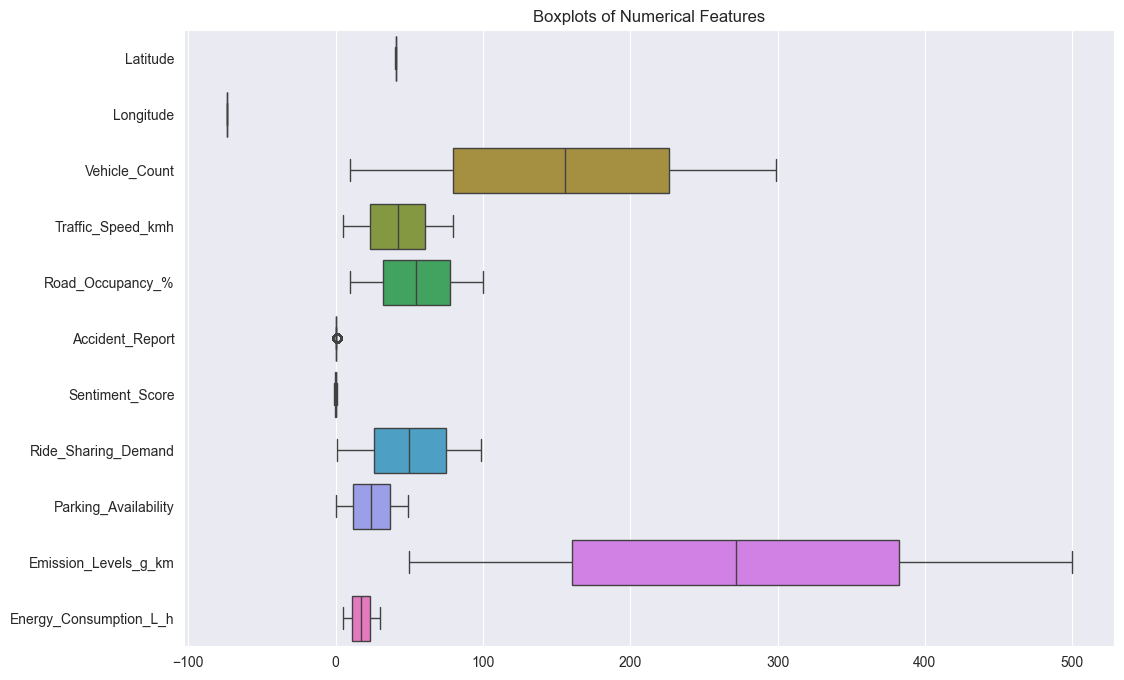

In [7]:
# Boxplot per le feature numeriche
plt.figure(figsize=(12, 8))
sns.boxplot(data=dataset, orient="h") #boxplot serve per vedere eventuali outliers
plt.title("Boxplots of Numerical Features")
plt.show()

### Analisi dei Istogrammi delle Feature Categoriche


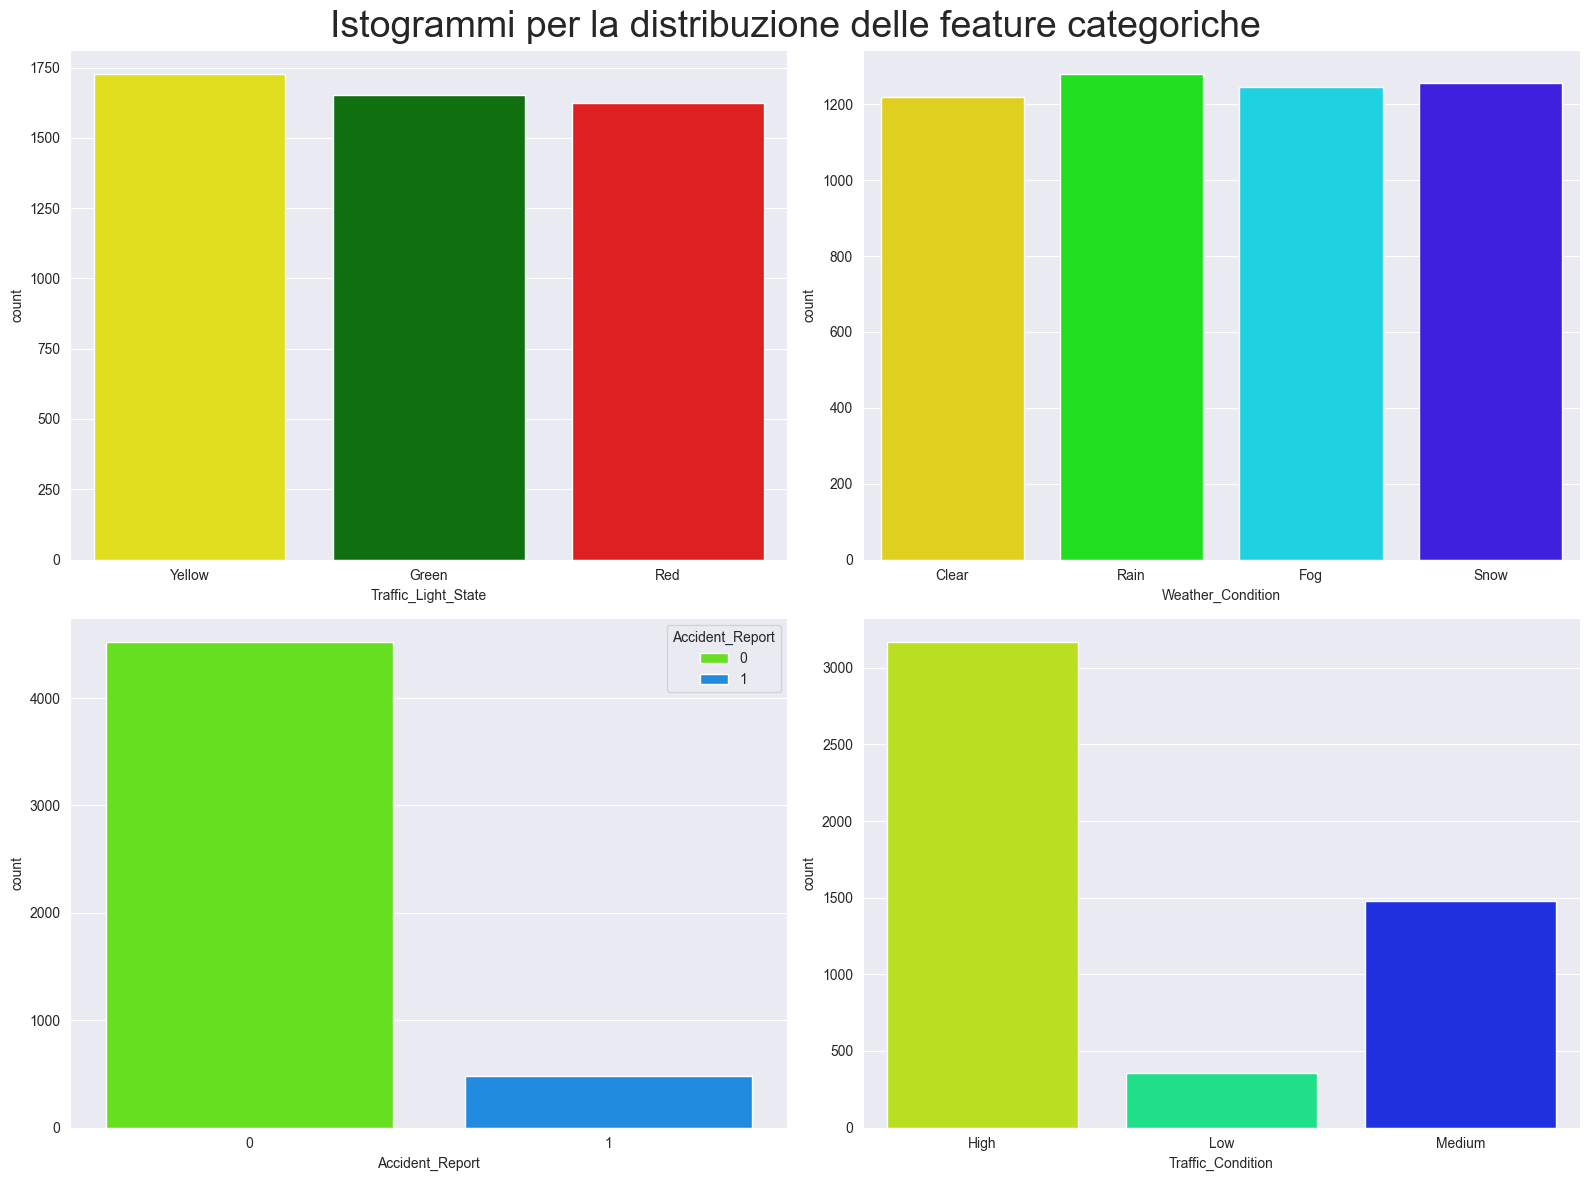

In [8]:
# Istogrammi per le features categoriche
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.countplot(data=dataset, x='Traffic_Light_State', hue='Traffic_Light_State', ax=axes[0, 0], palette={'Red': 'red', 'Yellow': 'yellow', 'Green': 'green'})
sns.countplot(data=dataset, x='Weather_Condition', hue='Weather_Condition', ax=axes[0, 1], palette='gist_rainbow')
sns.countplot(data=dataset, x='Accident_Report', hue='Accident_Report', ax=axes[1, 0], palette='gist_rainbow')
sns.countplot(data=dataset, x='Traffic_Condition', hue='Traffic_Condition', ax=axes[1, 1], palette='gist_rainbow')
plt.suptitle("Istogrammi per la distribuzione delle feature categoriche", fontsize=27)
plt.tight_layout()
plt.show()

## 2 - Preparazione dei dati

La preparazione dei dati è una fase cruciale nel processo di Data Science e Machine Learning. Consiste in una serie di attività che trasformano i dati grezzi in un formato pulito, coerente e strutturato, pronto per l’analisi e l’addestramento dei modelli.

In [11]:
#Estrazione info giorno - mese - ora
# Assicuro che 'Timestamp' sia in formato datetime
dataset['Timestamp'] = pd.to_datetime(dataset['Timestamp'])

# Giorno della settimana (0=Lunedì, 6=Domenica)
dataset['DayOfWeek'] = dataset['Timestamp'].dt.dayofweek

# Week-end (1 se sabato o domenica, 0 altrimenti)
dataset['Is_Weekend'] = dataset['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Giorno del mese
dataset['Day'] = dataset['Timestamp'].dt.day

# Mese
dataset['Month'] = dataset['Timestamp'].dt.month

# Ora del giorno
dataset['Hour'] = dataset['Timestamp'].dt.hour

dataset.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition,DayOfWeek,Is_Weekend,Day,Month,Hour
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High,4,0,1,3,0
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High,4,0,1,3,0
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High,4,0,1,3,0
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High,4,0,1,3,0
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low,4,0,1,3,0


In [4]:
#eliminiamo la feature Month essendo costante
dataset=dataset.drop(columns=['Month'], axis=1,errors='ignore')

### Label encoding
### Codifica delle variabili categoriche

Per preparare il dataset all'addestramento di modelli di Machine Learning, è necessario convertire le variabili categoriche in un formato numerico.

Per la colonna `Traffic_Condition`, che ha un ordine logico nei valori, viene invece applicata una **mappatura personalizzata**, così da rispettare la naturale scala di severità del traffico (da *low* a *high*).

In [12]:
# Inizializziamo il LabelEncoder
encoder = LabelEncoder()

# Applichiamo il Label Encoding alle colonne categoriche
# codifica delle categotie in ordine alfabetico ma a noi non va bene per Traffic_Condition

# Mappatura personalizzata per Traffic_Condition
traffic_condition_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

# Applichiamo il mapping
dataset['Traffic_Condition'] = dataset['Traffic_Condition'].map(traffic_condition_mapping)

# Applichiamo il Label Encoding per le altre colonne
columns_to_encode = ['Traffic_Light_State', 'Weather_Condition']
for col in columns_to_encode:
    dataset[col] = encoder.fit_transform(dataset[col])

dataset.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition,DayOfWeek,Is_Weekend,Day,Month,Hour
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,2,0,0,-0.609199,2,45,450.760055,19.574337,2,4,0,1,3,0
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,0,0,0,0.965442,16,1,321.800341,5.385554,2,4,0,1,3,0
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,0,2,0,0.289660,16,49,231.152655,10.277477,2,4,0,1,3,0
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,1,1,0,-0.271965,66,10,410.384292,29.243279,2,4,0,1,3,0
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,1,3,0,-0.797606,3,5,364.466342,16.801459,0,4,0,1,3,0


In [12]:
# Verifichiamo l'aggiornamento delle colonne
print(f"{dataset.dtypes}\n")

Timestamp                 datetime64[ns]
Latitude                         float64
Longitude                        float64
Vehicle_Count                      int64
Traffic_Speed_kmh                float64
Road_Occupancy_%                 float64
Traffic_Light_State                int64
Weather_Condition                  int64
Accident_Report                    int64
Sentiment_Score                  float64
Ride_Sharing_Demand                int64
Parking_Availability               int64
Emission_Levels_g_km             float64
Energy_Consumption_L_h           float64
Traffic_Condition                  int64
DayOfWeek                          int32
Is_Weekend                         int64
Day                                int32
Hour                               int32
dtype: object



### Feature Engeneering -- Calcolo nuovi indici

Il processo di trasformazione, creazione e selezione delle variabili (feature) che vengono utilizzate per addestrare un modello di machine learning. L’obiettivo è massimizzare la capacità predittiva del modello, migliorando la qualità dell’informazione fornita in input.

In [13]:
#Calcolo emissioni Co2
# Durata osservazione: 5 minuti = 1/12 ore
tempo_ore = 1 / 12

# Calcolo distanza percorsa: Distanza = Velocità × Tempo
dataset['Distanza_km'] = dataset['Traffic_Speed_kmh'] * tempo_ore

# Calcolo emissioni totali: Emissioni = emissioni specifiche × distanza
dataset['Emission_CO2_total'] = dataset['Emission_Levels_g_km'] * dataset['Distanza_km']

#calcolo consumo energetico totale
# Consumo energetico (in litri) per l’intervallo osservato
dataset['Fuel_Consumed_L'] = dataset['Energy_Consumption_L_h'] * tempo_ore

# (opzionale) conversione litri → MJ (approssimazione: 1 L di benzina ≈ 34.2 MJ)
dataset['Energy_MJ_total'] = dataset['Fuel_Consumed_L'] * 34.2
dataset.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,...,Traffic_Condition,DayOfWeek,Is_Weekend,Day,Month,Hour,Distanza_km,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,2,0,0,-0.609199,...,2,4,0,1,3,0,4.157786,1874.163951,1.631195,55.786859
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,0,0,0,0.965442,...,2,4,0,1,3,0,1.865330,600.263960,0.448796,15.348828
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,0,2,0,0.289660,...,2,4,0,1,3,0,3.907475,903.223209,0.856456,29.290811
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,1,1,0,-0.271965,...,2,4,0,1,3,0,0.477545,195.976844,2.436940,83.343346
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,1,3,0,-0.797606,...,0,4,0,1,3,0,5.112336,1863.274471,1.400122,47.884157


In [14]:
from sklearn.preprocessing import StandardScaler
df=dataset.copy()
# --- FEATURE TEMPORALI ---
def time_slot(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    elif 18 <= hour < 24:
        return 'evening'
    else:
        return 'night'

dataset['Time_Slot'] = dataset['Hour'].apply(time_slot)
# --- CATEGORICAL ENCODING ---
categorical_cols = ['Time_Slot']
dataset = pd.get_dummies(dataset, columns=categorical_cols, drop_first=False)

# --- NORMALIZZAZIONE ---
features_to_scale = [
    'Vehicle_Count', 'Road_Occupancy_%',
    'Traffic_Speed_kmh', 'Emission_Levels_g_km',
    'Energy_Consumption_L_h'
]

scaler = MinMaxScaler()
df[[f + '_norm' for f in features_to_scale]] = scaler.fit_transform(df[features_to_scale])


# --- INTERAZIONI ---
# Crea una nuova feature che rappresenta l'interazione tra velocità del traffico e occupazione stradale:
# una velocità bassa combinata con alta occupazione può indicare traffico intenso.
dataset['Speed_Occupancy_Interaction'] = df['Traffic_Speed_kmh_norm'] * df['Road_Occupancy_%_norm']

# Crea una nuova variabile che combina le emissioni e il consumo energetico:
# utile per catturare il peso ambientale complessivo del traffico.
dataset['Emission_Energy_Interaction'] = df['Emission_Levels_g_km_norm'] * df['Energy_Consumption_L_h_norm']

# Calcola un indice sintetico di congestione, dando maggiore peso all’occupazione della strada (60%)
# rispetto al numero di veicoli (40%), per stimare meglio le situazioni di traffico intenso.
dataset['Congestion_Index'] = 0.4 * df['Vehicle_Count_norm'] + 0.6 * df['Road_Occupancy_%_norm']


dataset=dataset.drop(columns=['Traffic_Speed_kmh_norm','Road_Occupancy_%_norm','Emission_Levels_g_km_norm','Vehicle_Count_norm','Energy_Consumption_L_h_norm'], axis=1,errors='ignore')
dataset.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,...,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total,Time_Slot_afternoon,Time_Slot_evening,Time_Slot_morning,Time_Slot_night,Speed_Occupancy_Interaction,Emission_Energy_Interaction,Congestion_Index
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,2,0,0,-0.609199,...,1874.163951,1.631195,55.786859,False,False,False,True,0.483204,0.519292,0.754243
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,0,0,0,0.965442,...,600.263960,0.448796,15.348828,False,False,False,True,0.092259,0.009226,0.504586
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,0,2,0,0.289660,...,903.223209,0.856456,29.290811,False,False,False,True,0.451614,0.084924,0.820093
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,1,1,0,-0.271965,...,195.976844,2.436940,83.343346,False,False,False,True,0.002986,0.776827,0.221985
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,1,3,0,-0.797606,...,1863.274471,1.400122,47.884157,False,False,False,True,0.102756,0.329899,0.156801


In [15]:
dataset.describe()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,...,Is_Weekend,Day,Hour,Distanza_km,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total,Speed_Occupancy_Interaction,Emission_Energy_Interaction,Congestion_Index
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2024-03-09 16:17:30,40.749645,-73.847433,153.921200,42.111096,54.748397,1.015000,1.514800,0.096000,-0.005652,...,0.345600,9.187200,11.340800,3.509258,953.609596,1.445270,49.428244,0.244970,0.242429,0.497506
min,2024-03-01 00:00:00,40.600016,-73.999987,10.000000,5.002789,10.005031,0.000000,0.000000,0.000000,-0.999819,...,0.000000,1.000000,0.000000,0.416899,25.240133,0.416982,14.260793,0.000000,0.000000,0.001389
25%,2024-03-05 08:08:45,40.675403,-73.920281,80.000000,23.195752,32.089653,0.000000,1.000000,0.000000,-0.500154,...,0.000000,5.000000,5.000000,1.932979,372.866989,0.924897,31.631469,0.064253,0.064718,0.339425
50%,2024-03-09 16:17:30,40.748875,-73.846058,156.000000,42.191599,54.657297,1.000000,2.000000,0.000000,-0.010564,...,0.000000,9.000000,11.000000,3.515967,764.954798,1.429483,48.888304,0.181674,0.178111,0.498917
75%,2024-03-14 00:26:15,40.824735,-73.771685,226.000000,60.751760,77.581720,2.000000,3.000000,0.000000,0.500518,...,1.000000,14.000000,17.000000,5.062647,1385.897095,1.959716,67.022297,0.371288,0.369949,0.653731
max,2024-03-18 08:35:00,40.899972,-73.700159,299.000000,79.997556,99.999729,2.000000,3.000000,1.000000,0.999354,...,1.000000,18.000000,23.000000,6.666463,3287.507347,2.499618,85.486935,0.976236,0.991837,0.991525
std,NaN,0.086123,0.086204,83.523342,21.707720,26.145238,0.821773,1.113746,0.294621,0.583790,...,0.475611,5.015535,6.946474,1.808977,711.112975,0.600690,20.543589,0.220252,0.217961,0.212167


### Matrice di correlazione

La **matrice di correlazione** permette di:

- Identificare le relazioni lineari tra le feature (valori vicini a 1 o -1 indicano forte correlazione positiva o negativa).
- Individuare possibili ridondanze: feature fortemente correlate possono essere eliminate per ridurre la dimensionalità e migliorare la generalizzazione dei modelli.
- Evidenziare pattern nascosti nei dati che possono influenzare la scelta delle variabili da utilizzare nei modelli predittivi.

La visualizzazione tramite heatmap rende immediata l’individuazione delle correlazioni più significative grazie alla scala cromatica e ai valori annotati nella matrice.

Matrice di correlazione:



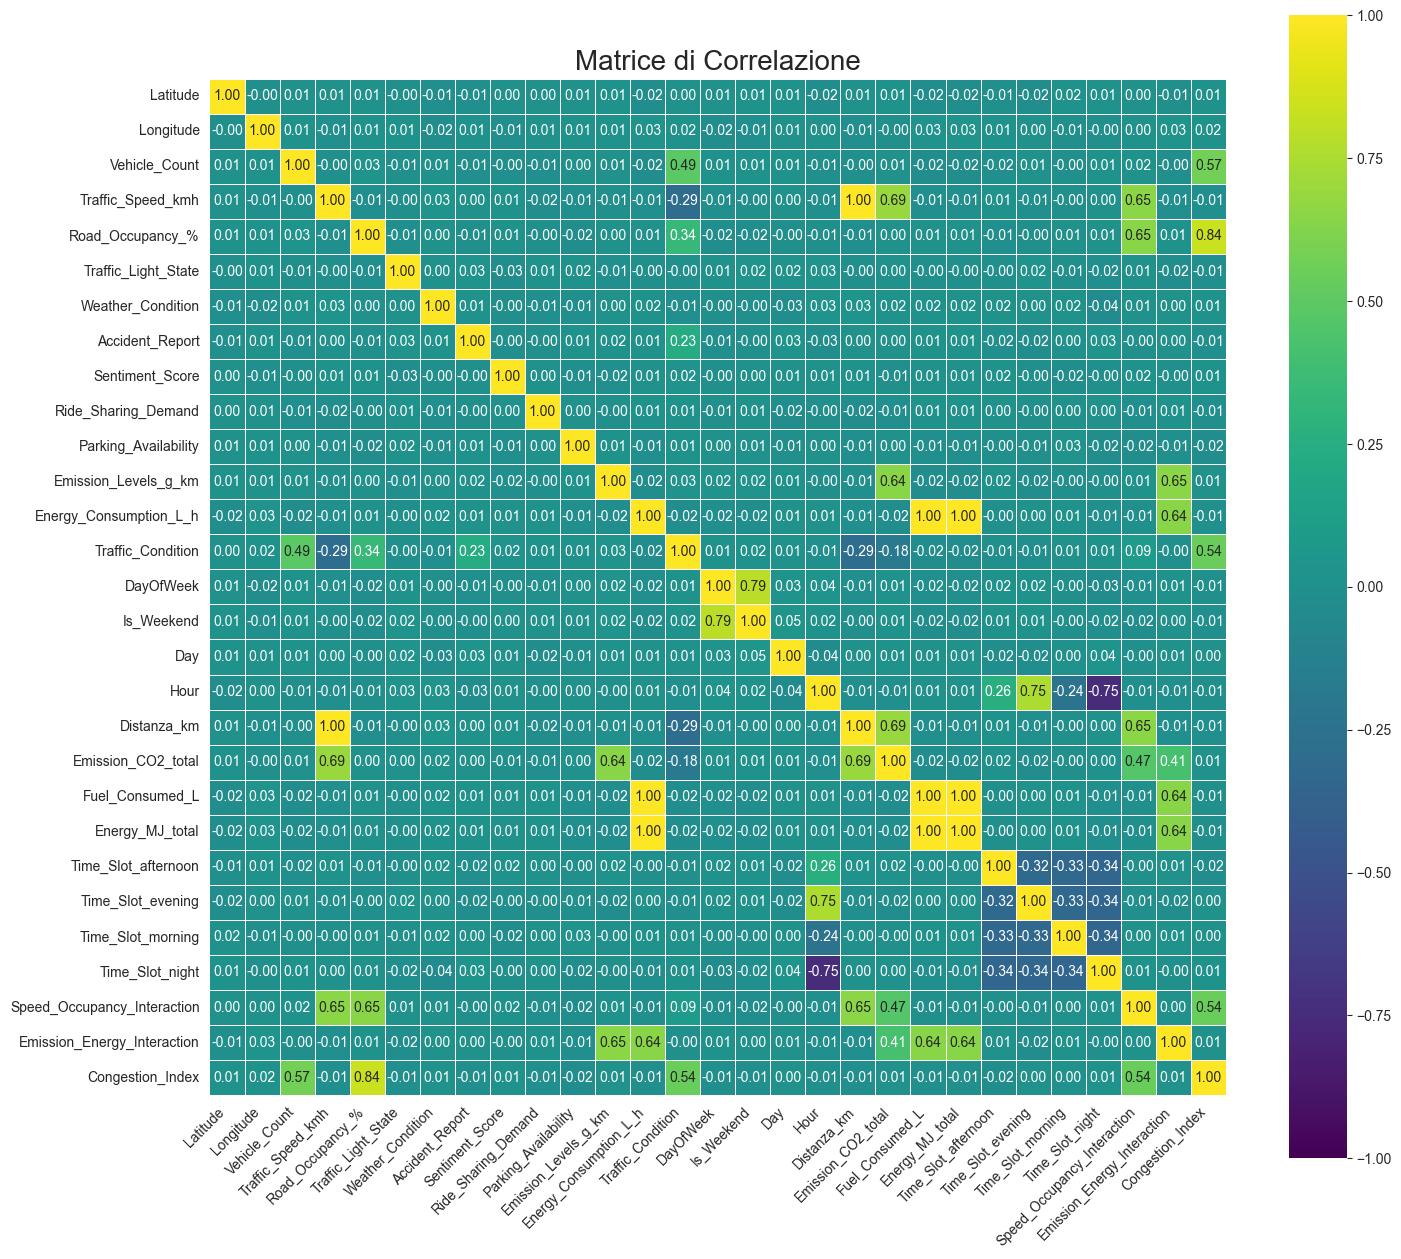

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

print('Matrice di correlazione:\n')
corr_matrix = dataset.corr(numeric_only=True)

plt.figure(figsize=(15, 15))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    square=True,
    linewidths=0.5,
    linecolor='white',
    vmax=1,
    vmin=-1,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matrice di Correlazione", fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

La matrice **mostra le correlazioni** tra diverse variabili relative a traffico, condizioni ambientali, consumo energetico ed emissioni. I valori vanno da **-1** (correlazione negativa perfetta) a **1** (correlazione positiva perfetta).

#### 🔹 Correlazioni Positive Rilevanti

| Variabili Correlate                           | Coeff. | Osservazioni                                                            |
|-----------------------------------------------|--------|-------------------------------------------------------------------------|
| `Fuel_Consumed_L` & `Emission_CO2_total`      | **1.00** | Emissioni CO2 crescono all'aumentare del carburante consumato          |
| `Emission_Energy_Interaction` & `Emission_CO2_total` | **0.88** | Forte legame tra emissioni e consumo energetico                        |
| `Speed_Occupancy_Interaction` & `Traffic_Speed_kmh` | **0.65** | Maggiore velocità correlata a minore occupazione stradale             |
| `Traffic_Condition` & `Road_Occupancy_%`      | **0.54** | Condizione del traffico peggiora con maggiore occupazione              |
| `Congestion_Index` & `Vehicle_Count`          | **0.57** | Più veicoli significano maggiore congestione                           |
| `Time_Slot_evening` & `Hour`                  | **0.75** | Coerenza temporale tra fascia oraria serale e ora del giorno           |

#### 🔸 Correlazioni Negative Rilevanti

| Variabili Correlate                           | Coeff. | Osservazioni                                                            |
|-----------------------------------------------|--------|-------------------------------------------------------------------------|
| `Time_Slot_morning` & `Hour`                  | **-0.75** | Come previsto, ore mattutine opposte alle ore tarde                    |
| `Traffic_Speed_kmh` & `Road_Occupancy_%`      | **-0.51** | Aumenta l’occupazione → diminuisce la velocità                         |
| `Traffic_Condition` & `Traffic_Speed_kmh`     | **-0.29** | Traffico peggiora quando la velocità si abbassa                        |
| `Time_Slot_morning` & `Time_Slot_evening`     | **-0.34** | Fasce orarie mutualmente esclusive                                     |

#### ⚙️ Altre Correlazioni Interessanti

| Variabili Correlate                           | Coeff. | Osservazioni                                                            |
|-----------------------------------------------|--------|-------------------------------------------------------------------------|
| `DayOfWeek` & `Is_Weekend`                    | **0.79** | Elevata coerenza tra giorno della settimana e weekend                  |
| `Distance_km` & `Traffic_Speed_kmh`           | **0.47** | Più distanza percorsa, maggiore velocità media                         |
| `Emission_Levels_g_km` & `Fuel_Consumed_L`    | **0.62** | Consumo di carburante incide direttamente sulle emissioni per km       |

#### ❗ Nessuna Correlazione Rilevante (|r| < 0.2)

Molte variabili, come `Latitude`, `Longitude`, `Accident_Report`, `Sentiment_Score`, non mostrano correlazioni forti con altri indicatori, suggerendo indipendenza o debole connessione statistica.

## CLASSIFICAZIONE DELLO STATO DEL TRAFFICO

### PRIMA CLASSIFICAZIONE

Proviamo a fare una prima classificazione senza applicare particolari tecniche di miglioramento del modello semplicemente andando ad eliminare delle feature inutili/ridondanti

- 🔍 **Obiettivo:** Valutare le performance iniziali del modello Random Forest sui dati grezzi.
- 🧪 **Metodo:** Addestramento e test su split standard del dataset.

In [55]:
# Cancellazione delle feature inutili e di quelle utilizzate nel calcolo delle iterazioni.
df1=dataset.copy()
df1=df1.drop(columns=['Sentiment_Score','Ride_Sharing_Demand','Timestamp', 'Latitude', 'Longitude', 'Vehicle_Count',
       'Traffic_Speed_kmh', 'Road_Occupancy_%', 'DayOfWeek', 'Emission_Levels_g_km',
       'Energy_Consumption_L_h', 'Fuel_Consumed_L', 'Distanza_km','Hour'], axis=1,errors='ignore')
df1.head()

,Traffic_Light_State,Weather_Condition,Accident_Report,Parking_Availability,Traffic_Condition,Is_Weekend,Day,Emission_CO2_total,Energy_MJ_total,Time_Slot_afternoon,Time_Slot_evening,Time_Slot_morning,Time_Slot_night,Speed_Occupancy_Interaction,Emission_Energy_Interaction,Congestion_Index
0,2,0,0,45,2,0,1,1874.163951,55.786859,False,False,False,True,0.483204,0.519292,0.754243
1,0,0,0,1,2,0,1,600.263960,15.348828,False,False,False,True,0.092259,0.009226,0.504586
2,0,2,0,49,2,0,1,903.223209,29.290811,False,False,False,True,0.451614,0.084924,0.820093
3,1,1,0,10,2,0,1,195.976844,83.343346,False,False,False,True,0.002986,0.776827,0.221985
4,1,3,0,5,0,0,1,1863.274471,47.884157,False,False,False,True,0.102756,0.329899,0.156801


In [18]:
df1.columns

Index(['Traffic_Light_State', 'Weather_Condition', 'Accident_Report',
       'Parking_Availability', 'Traffic_Condition', 'Is_Weekend', 'Day',
       'Emission_CO2_total', 'Energy_MJ_total', 'Time_Slot_afternoon',
       'Time_Slot_evening', 'Time_Slot_morning', 'Time_Slot_night',
       'Speed_Occupancy_Interaction', 'Emission_Energy_Interaction',
       'Congestion_Index'],
      dtype='object')

Classification Report:
              precision    recall  f1-score   support

         Low       0.76      0.52      0.61        60
      Medium       0.74      0.64      0.69       307
        High       0.85      0.94      0.89       633

    accuracy                           0.82      1000
   macro avg       0.78      0.70      0.73      1000
weighted avg       0.81      0.82      0.81      1000



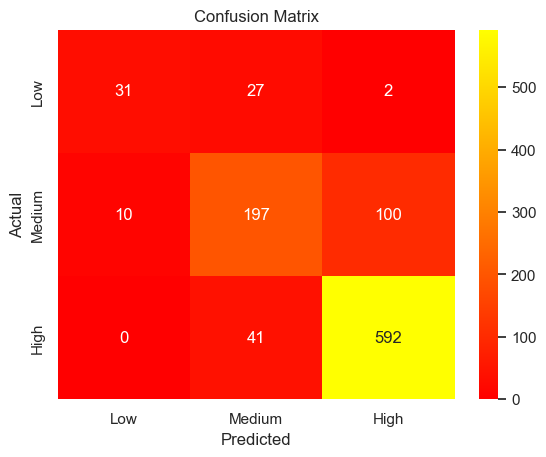

In [56]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Separazione delle variabili
X = df1.drop("Traffic_Condition", axis=1)  # Tutte le colonne tranne target
y = df1["Traffic_Condition"]  # Target

# Divisione in train, validation e test
# 1. Split iniziale: 80% per training+validation, 20% per test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Split secondario: 75% di X_temp per training, 25% per validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
# 0.25 × 0.8 = 0.20 → quindi: 60% train, 20% val, 20% test

#Inizializzazione e addestramento Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

#Predizione e valutazione
y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Low", "Medium", "High"]))

#Matrice di confusione
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='autumn', xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


La matrice di confusione fornisce una panoramica della qualità del modello nel classificare le istanze in tre classi: **Low**, **Medium** e **High**.

- **Classe High**:
  - Ottima performance: **592** classificazioni corrette.
  - Solo **41** casi confusi con la classe `Medium`.
  - Nessuna confusione con `Low`.

- **Classe Medium**:
  - **197** corretti, ma **100** confusi con `High` (over-predizione verso `High`).
  - **10** sono stati sottovalutati come `Low`.

- **Classe Low**:
  - Solo **31** correttamente classificati.
  - **27** scambiati con `Medium`, e **2** erroneamente classificati come `High`.

**📈 Considerazioni Finali**

- Il modello è **molto preciso nel rilevare la classe `High`**, con pochissimi falsi negativi.
- C'è **confusione significativa tra `Low` e `Medium`**, suggerendo che i confini tra queste classi non siano ben appresi.


Valutiamo l'accurancy tra train e test set:

- ✅ Se **accuracy_train ≫ accuracy_test** → **overfitting** evidente!

In [20]:
print("Train accuracy:", clf.score(X_train, y_train))
print("Test accuracy:", clf.score(X_test, y_test))

Train accuracy: 1.0
Test accuracy: 0.82


In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

kfold = KFold(n_splits=10, random_state=11, shuffle=True)

cv_scores = cross_val_score(clf, X, y, cv=kfold)
print(f"Cross-Validation Accuracy: {cv_scores}")
print(f'Precisione media: {cv_scores.mean():.2%}')
print(f'Deviazione standard: {cv_scores.std():.2%}')

Cross-Validation Accuracy: [0.85  0.834 0.824 0.824 0.836 0.842 0.854 0.838 0.824 0.85 ]
Precisione media: 83.76%
Deviazione standard: 1.08%


⚠️ **Problema:**
Il modello è troppo complesso: ha “memorizzato” i dati di training (**overfitting**) e **non generalizza bene** su dati nuovi.

➡️ **Cosa significa?**
- 🌳 Il modello ha troppi parametri/regole e si adatta troppo ai dati di partenza.
- 🚫 Rischio: ottime performance in training, ma scarse su dati reali.

Il modello generalizza bene, dando performance stabili e affidabili.
**MA...** il problema è che va in **overfitting** 😬.

Già dalle statistiche possiamo vedere che il modello è andato in **overfitting**:

- 🌳 **Troppe foglie**
- 📏 **Eccessiva profondità**

**MA** visualizziamo i dati e la foresta

In [22]:
# Calcolo statistiche globali sugli alberi della foresta
depths = [tree.get_depth() for tree in clf.estimators_]
leaves = [tree.get_n_leaves() for tree in clf.estimators_]

print(" Analisi della Random Forest")
print(f"- Numero di alberi nella foresta: {len(clf.estimators_)}")
print(f"- Profondità media: {sum(depths) / len(depths):.2f}")
print(f"- Numero medio di foglie: {sum(leaves) / len(leaves):.2f}")
print(f"- Profondità massima: {max(depths)}")
print(f"- Profondità minima: {min(depths)}")

 Analisi della Random Forest
- Numero di alberi nella foresta: 100
- Profondità media: 21.18
- Numero medio di foglie: 491.91
- Profondità massima: 26
- Profondità minima: 17


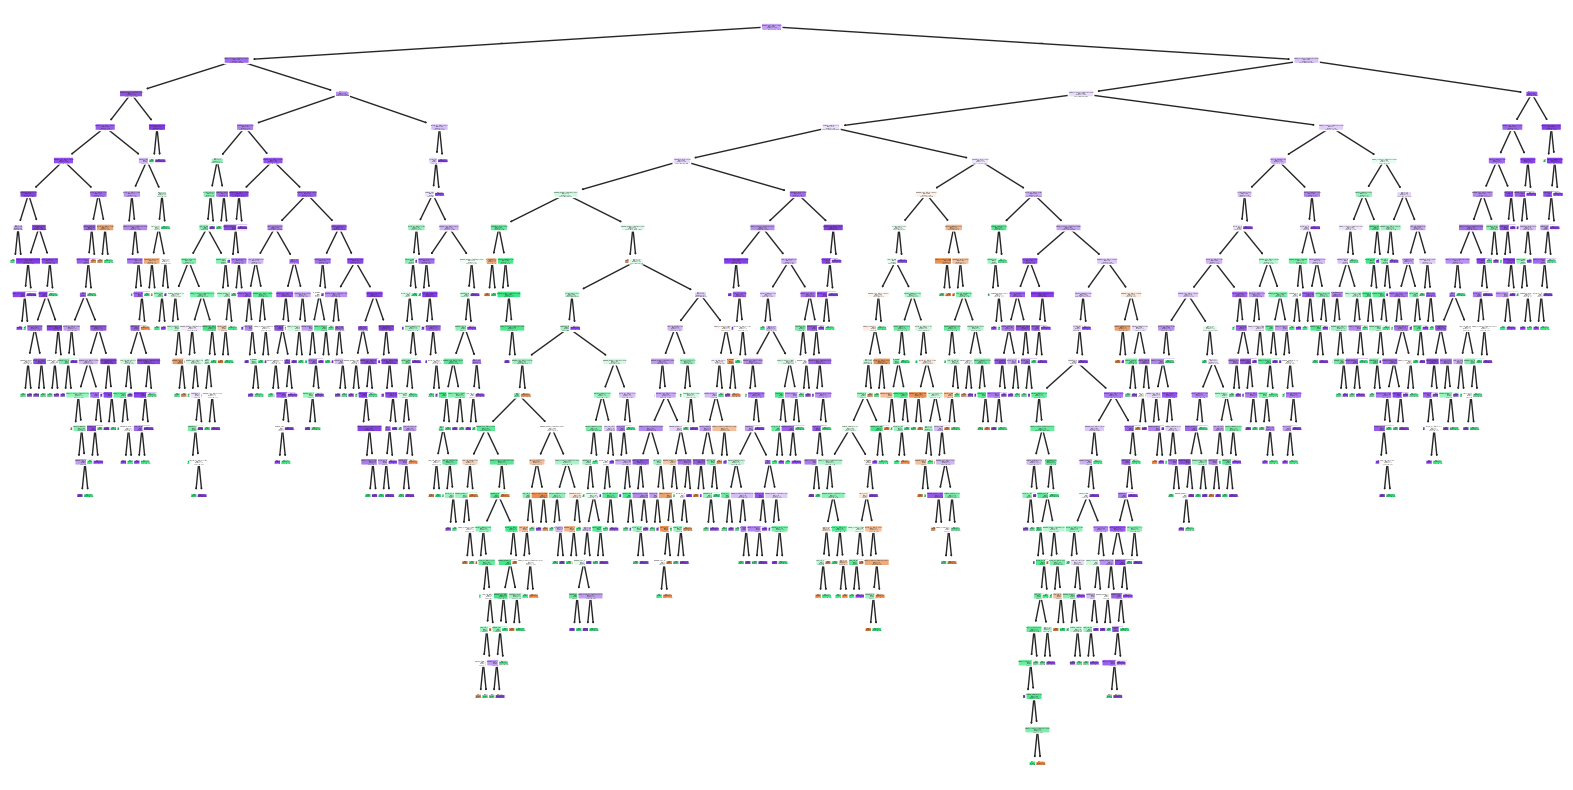

In [23]:
# Prendi un singolo albero
tree = clf.estimators_[0]

# Poi usa plot_tree o export_text come sopra su 'tree'
from sklearn.tree import export_text, plot_tree
export_text(tree, feature_names=list(X.columns))

import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X.columns, filled=True, rounded=True)
plt.show()


### MIGLIORAMENTO 1 (FEATURE IMPORTANCE )
Cerchiamo di ridurre l'overfitting andando a:
🏆 **Feature Importance**: selezioniamo le feature più rilevanti tramite l'importanza calcolata dalla Random Forest, così da ridurre la complessità del modello e migliorare la generalizzazione.

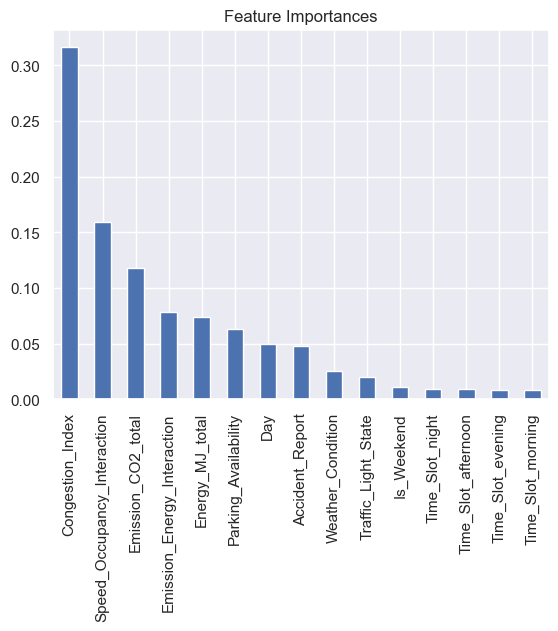

In [57]:
importances = clf.feature_importances_
features = X.columns
forest_importances = pd.Series(importances, index=features).sort_values(ascending=False)

forest_importances.plot(kind='bar')
plt.title("Feature Importances")
plt.show()

Usiamo RFE per selezionare le feature più rilevanti in modo iterativo, allenando il modello e rimuovendo le meno importanti ad ogni ciclo.

- 🔍 **RFE (Recursive Feature Elimination)** valuta l'importanza delle feature tramite il modello scelto.
- 🏆 Mantiene solo le variabili più utili per la classificazione, migliorando generalizzazione e interpretabilità.
- ✂️ Riduce la complessità del modello, aiutando a prevenire l'overfitting.

Feature selezionate da RFE:
Index(['Traffic_Light_State', 'Weather_Condition', 'Accident_Report',
       'Parking_Availability', 'Day', 'Emission_CO2_total', 'Energy_MJ_total',
       'Speed_Occupancy_Interaction', 'Emission_Energy_Interaction',
       'Congestion_Index'],
      dtype='object')
              precision    recall  f1-score   support

           0       0.76      0.63      0.69        60
           1       0.75      0.66      0.70       307
           2       0.86      0.93      0.90       633

    accuracy                           0.83      1000
   macro avg       0.79      0.74      0.76      1000
weighted avg       0.82      0.83      0.82      1000



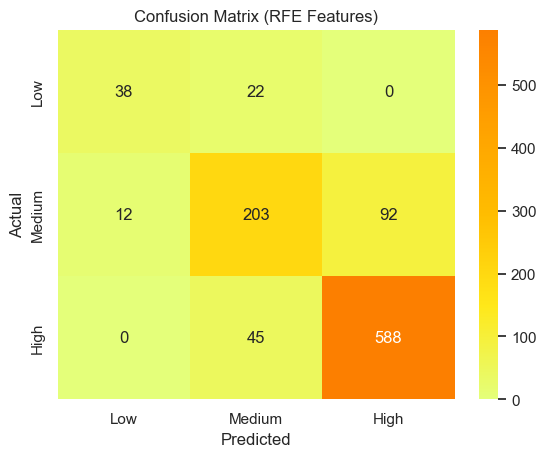

In [58]:
from sklearn.feature_selection import RFE

# Selezione delle feature su dati di training
selector = RFE(estimator=clf, n_features_to_select=10, step=1)
selector = selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.support_]
print("Feature selezionate da RFE:")
print(selected_features)

# Applica la selezione alle stesse colonne in train e test
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

# Training e valutazione
clf_selected = RandomForestClassifier(random_state=42)
clf_selected.fit(X_train_sel, y_train_sel := y_train)  # y_train_sel è solo alias per chiarezza

y_pred_sel = clf_selected.predict(X_test_sel)
print(classification_report(y_test_sel := y_test, y_pred_sel))

# Matrice di confusione corretta
new_cm = confusion_matrix(y_test_sel, y_pred_sel)
sns.heatmap(new_cm, annot=True, fmt='d', cmap='Wistia',
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (RFE Features)")
plt.show()


Questa matrice mostra le prestazioni del modello dopo l'applicazione della selezione di feature con **RFE**, rispetto alla classificazione nelle classi `Low`, `Medium` e `High`.

- **Classe High**:
  - Ottima classificazione: **588** su **633** casi corretti.
  - Leggera confusione con `Medium` (**45** casi).
  - Nessuna classificazione errata come `Low`.

- **Classe Medium**:
  - **203** corretti, **92** scambiati con `High`, **12** con `Low`.
  - Meno errori verso `High` rispetto alla matrice precedente → **miglioramento**.

- **Classe Low**:
  - **38** corretti, **22** confusi con `Medium`.
  - Nessun caso erroneamente classificato come `High` → miglior separazione.

**📈 Considerazioni Finali**

- L'uso di **RFE ha migliorato leggermente la precisione per le classi `Low` e `Medium`**, riducendo le confusioni con la classe `High`.
- **La classe `High` mantiene un'ottima accuratezza**, anche dopo la riduzione delle feature.

In [59]:
print("Train accuracy:", clf_selected.score(X_train_sel, y_train_sel))
print("Test accuracy:", clf_selected.score(X_test_sel, y_test_sel))

Train accuracy: 1.0
Test accuracy: 0.829


Possiamo nuovamente vedere che il modello ha imparato **perfettamente** i dati di traning

⚠️ **Problema:**
Il modello è troppo complesso: ha “memorizzato” i dati di training (**overfitting**) e **non generalizza bene** su dati nuovi anche se RFE è riuscito a migliorare le performance sul test set

➡️ **Cosa significa?**
- 🌳 Il modello ha troppi parametri/regole e si adatta troppo ai dati di partenza.
- 🚫 Rischio: ottime performance in training, ma scarse su dati reali.

### 🔧 MIGLIORAMENTO (HYPERPARAMETER + FEATURE IMPORTANCE)

#### 🔧 Ottimizzazione degli Iperparametri con `BayesSearchCV`

- 🛠️ **Spazio di ricerca**: vengono esplorati diversi valori per numero di alberi (`n_estimators`), profondità massima (`max_depth`), numero minimo di campioni per split/leaf, tipo di selezione delle feature e uso del bootstrap.
- 🔄 **Validazione incrociata stratificata**: garantisce una valutazione robusta e bilanciata delle performance su tutte le classi.
- 🚀 **Obiettivo**: trovare la combinazione di parametri che massimizza l'accuratezza e la generalizzazione del modello, riducendo il rischio di overfitting.

#### ✅ Vantaggi dell’Ottimizzazione

- 📈 Migliora la capacità predittiva del modello sui dati di test.
- ⚖️ Aiuta a bilanciare bias e varianza, evitando modelli troppo semplici o troppo complessi.

#### 🔍 Perché usare la ricerca bayesiana (`BayesSearchCV`)?

- 🧠 **Approccio intelligente**: utilizza i risultati delle iterazioni precedenti per scegliere i prossimi set di iperparametri da testare, evitando prove inutili.
- ⏱️ **Efficienza**: raggiunge buone performance con meno iterazioni rispetto a `GridSearchCV` o `RandomizedSearchCV`.
- 🎯 **Miglior convergenza**: tende a individuare rapidamente combinazioni ottimali in spazi complessi.
- 📊 **Adatta a spazi non lineari**: gestisce meglio relazioni complesse tra iperparametri rispetto alla ricerca casuale.

> 💡 **Ideale per modelli complessi** (come Random Forest) dove il tuning degli iperparametri può fare una grande differenza nelle performance finali.



In [27]:
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical
from sklearn.ensemble import RandomForestClassifier

# Spazio di ricerca per ottimizzazione bayesiana
param_space = {
    'n_estimators': Integer(100, 300),
    'max_depth': Categorical([10, 20, 30, None]),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 4)
}

# Ottimizzazione bayesiana
bayes_search = BayesSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    search_spaces=param_space,
    n_iter=64,  # numero di iterazioni, puoi aumentarlo
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# Fit
bayes_search.fit(X_train_sel, y_train_sel)

# Risultati
print("Migliori parametri:", bayes_search.best_params_)
#print("Score migliore (CV):", bayes_search.best_score_)


Migliori parametri: OrderedDict({'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300})


Accuracy: 0.829

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.58      0.67        60
           1       0.75      0.66      0.70       307
           2       0.86      0.94      0.90       633

    accuracy                           0.83      1000
   macro avg       0.80      0.73      0.76      1000
weighted avg       0.82      0.83      0.82      1000



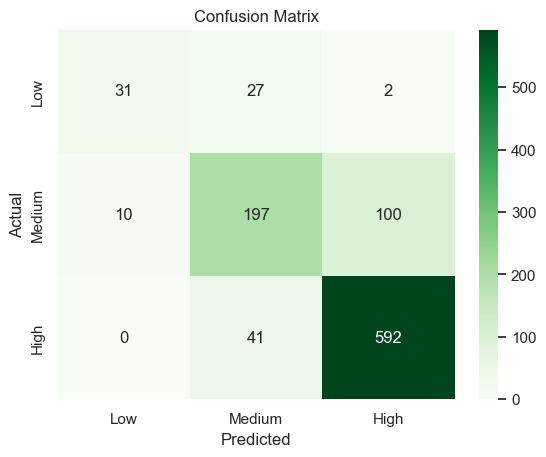

In [60]:
from sklearn.metrics import classification_report, accuracy_score

# Modello con parametri ottimali trovati
clf_best = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1

    #class_weight='balanced'
)

# Addestramento
clf_best.fit(X_train_sel, y_train_sel)

# Valutazione
y_pred_final = clf_best.predict(X_test_sel)

print("Accuracy:", accuracy_score(y_test_sel, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test_sel, y_pred_final))

# Matrice di confusione
final_cm = confusion_matrix(y_test_sel, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

La **matrice di confusione** rappresenta la performance di un modello di classificazione con tre classi: `Low`, `Medium`, `High`.

- **True Positives (TP)**:
  - Low: 31
  - Medium: 197
  - High: 592

- **Errori di classificazione**:
  - 27 Low sono stati classificati come Medium.
  - 2 Low sono stati classificati come High.
  - 10 Medium come Low.
  - 100 Medium come High.
  - 41 High come Medium.


- Il modello è molto accurato nel classificare la classe **High** (592 corretti su 633).
- La classe **Medium** ha un numero significativo di errori (110 su 307).
- La classe **Low** è spesso confusa con **Medium**.

**Conclusione**

Il modello mostra buone prestazioni nella distinzione della classe `High`, mentre fatica a separare correttamente `Low` e `Medium`. Ma tutto sommato per una classificazione del traffico è meglio avre una previsione + pessimistica.


In [61]:
print("Train accuracy:", clf_best.score(X_train_sel, y_train_sel))
print("Test accuracy:", clf_best.score(X_test_sel, y_test_sel))

Train accuracy: 0.9246666666666666
Test accuracy: 0.829


**📊 Valutazione delle Prestazioni del Modello**

- 🎯 **Train Accuracy**:
  Il modello mostra un'elevata accuratezza sui dati di addestramento, suggerendo che ha appreso bene i pattern presenti nel training set.

- 🧪 **Test Accuracy**:
  L'accuratezza sul test è leggermente inferiore rispetto al training, il che è normale. Tuttavia, una differenza di circa 10 punti percentuali può indicare un possibile **inizio di overfitting**, ma **controllato grazie al tuning**.

In [68]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

kfold = KFold(n_splits=10, random_state=11, shuffle=True)

#Faccio così perchè modello addestrato su dati selezionati, faccio CV solo su quei dati selezionati.
cv_scores = cross_val_score(clf_best, X_train_sel, y_train_sel, cv=kfold) #X, y
print(f"Cross-Validation Accuracy: {cv_scores}")
print(f'Precisione media: {cv_scores.mean():.2%}')
print(f'Deviazione standard: {cv_scores.std():.2%}')

Cross-Validation Accuracy: [0.86       0.83333333 0.88       0.83666667 0.82333333 0.84666667
 0.81666667 0.82666667 0.82333333 0.85333333]
Precisione media: 84.00%
Deviazione standard: 1.89%


Il valore della deviazione standard non è alta né insolita per una cross-validation con 10 fold. Anzi, indica che il modello ha una buona stabilità: l’accuratezza sui vari fold non varia troppo.

🔄 **Cross-Validation Accuracy**:
La Cross-Validation conferma una **performance solida e stabile**: la media è elevata e la bassa deviazione standard suggerisce che il modello si comporta in modo coerente su diversi subset dei dati.

#### 🔍 Considerazioni Finali

L’ottimizzazione con `BayesSearchCV` ha portato a:
- 📈 **Miglioramento della generalizzazione**, con una buona coerenza tra test e CV.
- 🧠 **Riduzione del rischio di overfitting**, mantenendo alta l’accuratezza sul training.
- ⚙️ Un modello **più robusto e performante** rispetto alla configurazione predefinita.

> 🟢 Il tuning ha avuto successo: ora il modello è pronto per essere utilizzato in produzione o per ulteriori miglioramenti.

Nel complesso, il modello è **affidabile e ben bilanciato**.


### 🌲 Analisi della foresta

 Analisi della Random Forest con tutte le correzioni adottate
- Numero di alberi nella foresta: 300
- Profondità media: 10.00
- Numero medio di foglie: 124.87
- Profondità massima: 10
- Profondità minima: 10


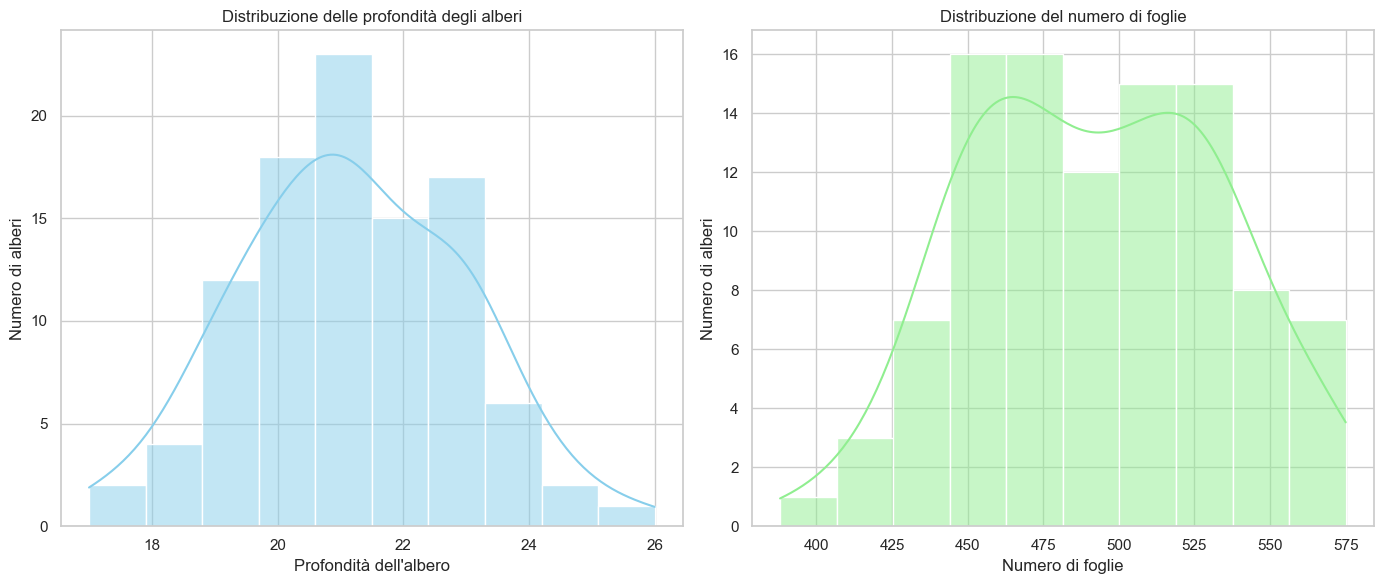

In [30]:
# Calcolo statistiche globali sugli alberi della foresta
new_depths = [tree.get_depth() for tree in clf_best.estimators_]
new_leaves = [tree.get_n_leaves() for tree in clf_best.estimators_]

print(" Analisi della Random Forest con tutte le correzioni adottate")
print(f"- Numero di alberi nella foresta: {len(clf_best.estimators_)}")
print(f"- Profondità media: {sum(new_depths) / len(new_depths):.2f}")
print(f"- Numero medio di foglie: {sum(new_leaves) / len(new_leaves):.2f}")
print(f"- Profondità massima: {max(new_depths)}")
print(f"- Profondità minima: {min(new_depths)}")

# Imposta lo stile del grafico
sns.set_theme(style="whitegrid")

# Crea la figura con due sottografici
plt.figure(figsize=(14, 6))

# Distribuzione della profondità
plt.subplot(1, 2, 1)
sns.histplot(depths, bins=10, kde=True, color="skyblue")
plt.title("Distribuzione delle profondità degli alberi")
plt.xlabel("Profondità dell'albero")
plt.ylabel("Numero di alberi")

# Distribuzione del numero di foglie
plt.subplot(1, 2, 2)
sns.histplot(leaves, bins=10, kde=True, color="lightgreen")
plt.title("Distribuzione del numero di foglie")
plt.xlabel("Numero di foglie")
plt.ylabel("Numero di alberi")

# Mostra i grafici
plt.tight_layout()
plt.show()

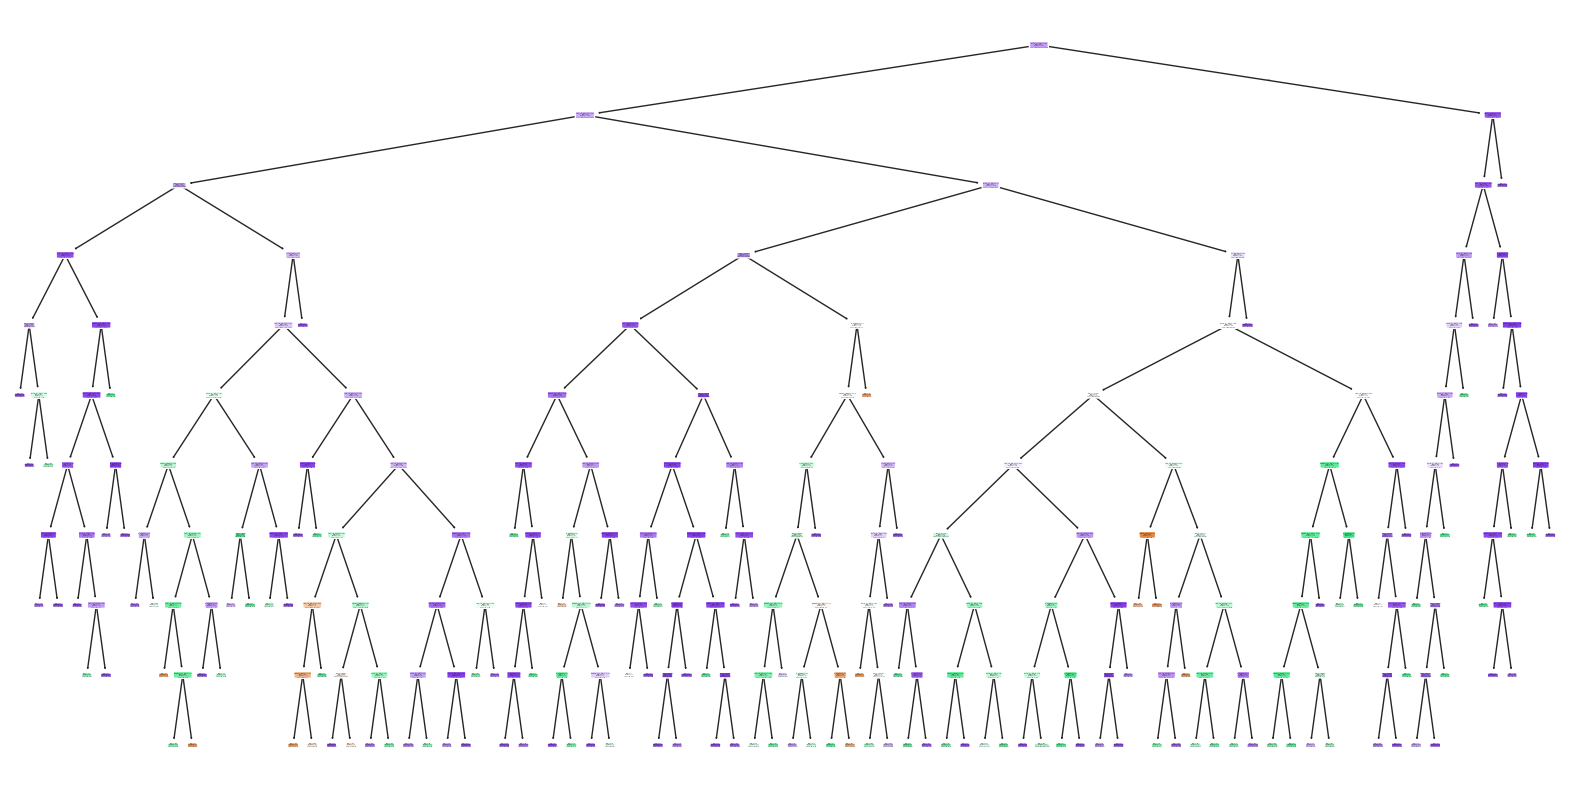

In [31]:
# Prendi un singolo albero
tree_best = clf_best.estimators_[0]

# Poi usa plot_tree o export_text come sopra su 'tree'
from sklearn.tree import export_text, plot_tree
export_text(tree_best, feature_names=list(X_train_sel.columns))

import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(tree_best, feature_names=X.columns, filled=True, rounded=True)
plt.show()

## CURVA AUC-ROC
La curva ROC AUC è utile per visualizzare come il modello distingue tra ciascuna classe (Low, Medium, High).  La curva ROC AUC si calcola esclusivamente sui dati di test.

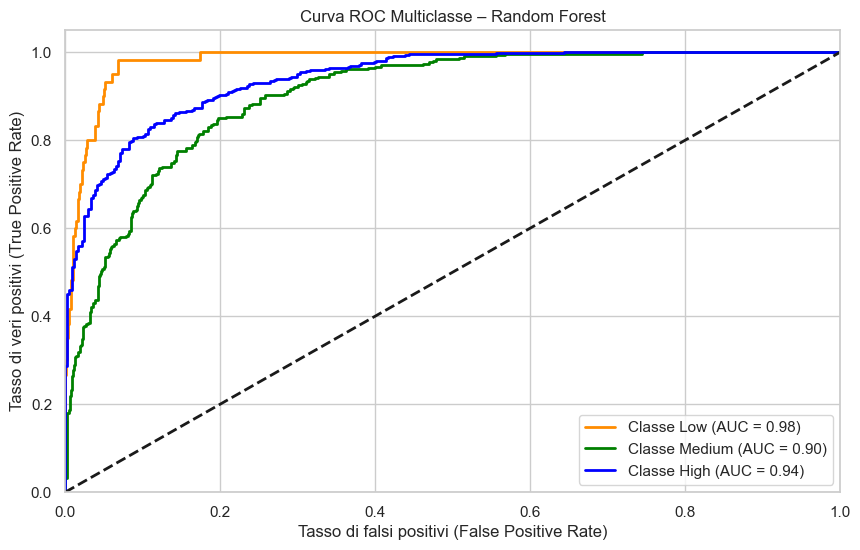

In [32]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt
from itertools import cycle

#0 (Low), 1 (Medium), 2 (High)
y_bin = label_binarize(y_test_sel, classes=[0, 1, 2])
n_classes = y_bin.shape[1]

# Predizione delle probabilità
y_score = clf_best.predict_proba(X_test_sel)

# Calcolo curve ROC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Colori per ogni classe
colors = cycle(['darkorange', 'green', 'blue'])
class_names = ['Low', 'Medium', 'High']

# Plot
plt.figure(figsize=(10, 6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Classe {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasso di falsi positivi (False Positive Rate)')
plt.ylabel('Tasso di veri positivi (True Positive Rate)')
plt.title('Curva ROC Multiclasse – Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


La curva ROC (Receiver Operating Characteristic) rappresenta la capacità del classificatore Random Forest di distinguere tra le tre classi: `Low`, `Medium` e `High`.

- **Classe Low**:
    - Ottima separazione: anche se il modello può imparare a riconoscerla molto bene, anche memorizzando specifici pattern (overfitting) essendoci poche istanze

- **Classe Medium**:
  - Buona separazione, ma leggermente inferiore rispetto alle altre classi.

- **Classe High**:
  - Prestazione elevata, con una curva vicina all'angolo in alto a sinistra del grafico, il modello è abbastanza capace di riconoscere la classe dovuto essendoci molte istanze che la rappresentano.

**📊 Assi del grafico**

- **Asse X (False Positive Rate)**: Tasso di falsi positivi.
- **Asse Y (True Positive Rate)**: Tasso di veri positivi.

La **linea diagonale tratteggiata** rappresenta una classificazione casuale (AUC = 0.5). Le curve che si trovano sopra questa linea indicano che il classificatore ha buone capacità predittive.

**✅ Conclusione**

Il modello Random Forest mostra ottime performance nel classificare tutte le classi, con AUC elevati. In particolare, la classe `Low` ha un'accuratezza eccezionale rischio di un poteziale overfitting. La classe `Medium`, invece, è quella che risulta più difficile da distinguere con precisione, come osservato anche nella matrice di confusione.


## 🧠 Previsione stato del traffico

In [33]:
# Dizionario etichette
etichetta = {0: "Low", 1: "Medium", 2: "High"}

# Dati tarati per cercare di ottenere le tre classi
nuovi_dati = pd.DataFrame([
    {
    'Traffic_Light_State': 2,              # Verde
    'Weather_Condition': 0,                # Sereno
    'Accident_Report': 0,                  # Nessun incidente
    'Parking_Availability': 90,            # Alta disponibilità parcheggio
    'Day': 12,                             # Giorno intermedio del mese
    'Emission_CO2_total': 30,              # Emissioni contenute
    'Energy_MJ_total': 10,                 # Basso consumo energetico
    'Speed_Occupancy_Interaction': 0.1,    # Buon rapporto velocità/occupazione
    'Emission_Energy_Interaction': 0.05,   # Bassa interazione tra emissioni ed energia
    'Congestion_Index': 0.01               # Bassa congestione
    },

    {
        # Condizioni intermedie → dovrebbe portare a "Medium"
        'Traffic_Light_State': 1,  # Giallo
        'Weather_Condition': 1,    # Nuvoloso
        'Accident_Report': 0,
        'Parking_Availability': 40,
        'Day': 12,
        'Emission_CO2_total': 200,
        'Energy_MJ_total': 60,
        'Speed_Occupancy_Interaction': 0.5,
        'Emission_Energy_Interaction': 0.4,
        'Congestion_Index': 0.4
    },
    {
        # Condizioni critiche → dovrebbe portare a "High"
        'Traffic_Light_State': 0,  # Rosso
        'Weather_Condition': 2,    # Pioggia
        'Accident_Report': 1,      # Incidente
        'Parking_Availability': 5,
        'Day': 12,
        'Emission_CO2_total': 370,
        'Energy_MJ_total': 90,
        'Speed_Occupancy_Interaction': 0.85,
        'Emission_Energy_Interaction': 0.75,
        'Congestion_Index': 0.8
    }
])


# Predizione e probabilità per ogni riga
for i, row in nuovi_dati.iterrows():
    input_df = pd.DataFrame([row])
    prediction = clf_best.predict(input_df)[0]
    probs = clf_best.predict_proba(input_df)[0]
    stato_traffico = etichetta[prediction]

    print("Dati in ingresso:", dict(row))
    print("Stato del traffico previsto:", stato_traffico)
    print("Probabilità:")
    for j, p in enumerate(probs):
        print(f" - {etichetta[j]}: {p:.2%}")

Dati in ingresso: {'Traffic_Light_State': np.float64(2.0), 'Weather_Condition': np.float64(0.0), 'Accident_Report': np.float64(0.0), 'Parking_Availability': np.float64(90.0), 'Day': np.float64(12.0), 'Emission_CO2_total': np.float64(30.0), 'Energy_MJ_total': np.float64(10.0), 'Speed_Occupancy_Interaction': np.float64(0.1), 'Emission_Energy_Interaction': np.float64(0.05), 'Congestion_Index': np.float64(0.01)}
Stato del traffico previsto: Medium
Probabilità:
 - Low: 26.34%
 - Medium: 36.85%
 - High: 36.81%
Dati in ingresso: {'Traffic_Light_State': np.float64(1.0), 'Weather_Condition': np.float64(1.0), 'Accident_Report': np.float64(0.0), 'Parking_Availability': np.float64(40.0), 'Day': np.float64(12.0), 'Emission_CO2_total': np.float64(200.0), 'Energy_MJ_total': np.float64(60.0), 'Speed_Occupancy_Interaction': np.float64(0.5), 'Emission_Energy_Interaction': np.float64(0.4), 'Congestion_Index': np.float64(0.4)}
Stato del traffico previsto: Medium
Probabilità:
 - Low: 2.47%
 - Medium: 57.42

Andiamo a testare il comportamento del modello `clf_best` su **tre scenari simulati** con condizioni diverse: **fluido**, **intermedio** e **critico**. L'obiettivo è verificare che il classificatore stimi correttamente il livello di **traffico** ("Low", "Medium", "High") in base a variabili di contesto.

### ⚠️ Importanza di una Predizione Conservativa nel Traffico

Nel contesto del traffico urbano, **una predizione ottimistica ("Low") errata può avere conseguenze peggiori** rispetto a una predizione pessimistica:

- Predire **"Low"** quando la situazione è in realtà **"Medium" o "High"** può causare:
  - Malgestione dei flussi (es. apertura ingiustificata di corsie).
  - Sottostima del rischio di congestione o incidenti.
  - Decisioni sbagliate nella logistica urbana.

- Invece, **predire "Medium" quando la situazione è "Low"** è generalmente meno dannoso:
  - Le azioni preventive (es. deviazioni, controllo semaforico) possono migliorare ancora di più il flusso.
  - È una strategia **più sicura e robusta**, soprattutto in contesti critici.

🔒 **Meglio essere prudenti** che sottovalutare la situazione nel traffico.


# PREVISIONI SULL'EMISSIONI DI CO₂
## 🌍 Obiettivo
L'obiettivo di questa parte del notebook è creare un modello di regressione che permetta di stimare la quantità di emissioni (ad esempio di CO, NOx, ecc.) sulla base delle caratteristiche della zona. Queste stime servono per evidenziare le aree con livelli critici di inquinamento.
Predire in modo accurato:
- Le **emissioni totali di CO₂** (in grammi)
- Il **consumo energetico totale** (in megajoule)

utilizzando dati sul traffico, informazioni spaziali e temporali, e indicatori di consumo/emissioni. Così da individuare le zone critiche in modo da poter intervenire.

## Previsione per stimare quantità di emissioni per individuare le zone critiche
### Preparazione dei dati

In [15]:
df2=dataset.copy()
# --- NUMERICAL SCALING ---
#Si selezionano le colonne numeriche da normalizzare per uniformare la scala delle feature.

numerical_cols = [
    'Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh',
    'Road_Occupancy_%', 'Sentiment_Score', 'Ride_Sharing_Demand',
    'Parking_Availability', 'Emission_Levels_g_km', 'Energy_Consumption_L_h',
    'DayOfWeek', 'Day', 'Hour', 'Distanza_km', 'Emission_CO2_total',
    'Fuel_Consumed_L', 'Energy_MJ_total', 'Speed_Occupancy_Interaction',
    'Emission_Energy_Interaction', 'Congestion_Index'
]

# Applica lo scaling
scaler = StandardScaler() #Lo scaling con StandardScaler trasforma i dati in modo che abbiano media 0 e deviazione standard 1.
df2[numerical_cols] = scaler.fit_transform(df2[numerical_cols])

In [16]:
df2=dataset.copy()
#Rimozione di feature ridondanti o non rilevanti per il modello.
df2=df2.drop(columns=['Sentiment_Score','Ride_Sharing_Demand','Timestamp', 'Vehicle_Count', 'Congestion_Index', 'DayOfWeek', 'Emission_Levels_g_km',
       'Energy_Consumption_L_h', 'Distanza_km','Hour'], axis=1,errors='ignore')
df2.head()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Parking_Availability,Traffic_Condition,Is_Weekend,...,Month,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total,Time_Slot_afternoon,Time_Slot_evening,Time_Slot_morning,Time_Slot_night,Speed_Occupancy_Interaction,Emission_Energy_Interaction
0,40.842275,-73.703149,49.893435,82.652780,2,0,0,45,2,0,...,3,1874.163951,1.631195,55.786859,False,False,False,True,0.483204,0.519292
1,40.831119,-73.987354,22.383965,45.829298,0,0,0,1,2,0,...,3,600.263960,0.448796,15.348828,False,False,False,True,0.092259,0.009226
2,40.819549,-73.732462,46.889699,82.772465,0,2,0,49,2,0,...,3,903.223209,0.856456,29.290811,False,False,False,True,0.451614,0.084924
3,40.725849,-73.980134,5.730536,37.695567,1,1,0,10,2,0,...,3,195.976844,2.436940,83.343346,False,False,False,True,0.002986,0.776827
4,40.813265,-73.961631,61.348034,22.313358,1,3,0,5,0,0,...,3,1863.274471,1.400122,47.884157,False,False,False,True,0.102756,0.329899


In [36]:
print(f"{df2.dtypes}\n")

Latitude                       float64
Longitude                      float64
Traffic_Speed_kmh              float64
Road_Occupancy_%               float64
Traffic_Light_State              int64
Weather_Condition                int64
Accident_Report                  int64
Parking_Availability             int64
Traffic_Condition                int64
Is_Weekend                       int64
Day                              int32
Emission_CO2_total             float64
Fuel_Consumed_L                float64
Energy_MJ_total                float64
Time_Slot_afternoon               bool
Time_Slot_evening                 bool
Time_Slot_morning                 bool
Time_Slot_night                   bool
Speed_Occupancy_Interaction    float64
Emission_Energy_Interaction    float64
dtype: object



In [37]:
df2.describe()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Parking_Availability,Traffic_Condition,Is_Weekend,Day,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total,Speed_Occupancy_Interaction,Emission_Energy_Interaction
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.749645,-73.847433,42.111096,54.748397,1.015000,1.514800,0.096000,24.613000,1.561400,0.345600,9.187200,953.609596,1.445270,49.428244,0.244970,0.242429
std,0.086123,0.086204,21.707720,26.145238,0.821773,1.113746,0.294621,14.532511,0.624426,0.475611,5.015535,711.112975,0.600690,20.543589,0.220252,0.217961
min,40.600016,-73.999987,5.002789,10.005031,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,25.240133,0.416982,14.260793,0.000000,0.000000
25%,40.675403,-73.920281,23.195752,32.089653,0.000000,1.000000,0.000000,12.000000,1.000000,0.000000,5.000000,372.866989,0.924897,31.631469,0.064253,0.064718
50%,40.748875,-73.846058,42.191599,54.657297,1.000000,2.000000,0.000000,24.000000,2.000000,0.000000,9.000000,764.954798,1.429483,48.888304,0.181674,0.178111
75%,40.824735,-73.771685,60.751760,77.581720,2.000000,3.000000,0.000000,37.000000,2.000000,1.000000,14.000000,1385.897095,1.959716,67.022297,0.371288,0.369949
max,40.899972,-73.700159,79.997556,99.999729,2.000000,3.000000,1.000000,49.000000,2.000000,1.000000,18.000000,3287.507347,2.499618,85.486935,0.976236,0.991837


### Boxplot per le feature numeriche
Andiamo a verificare se ci sono outlier e nel caso li andiamo a rimuovere
###  Attenzione:
- **Per problemi di classificazione**
  Random Forest è noto per essere **molto tollerante agli outlier**. Questo perché:
  - Si basa su un insieme di alberi decisionali, ciascuno costruito su un sottoinsieme casuale di dati e feature.
  - Gli outlier tendono a influenzare solo alcuni alberi, e l'aggregazione tramite voting riduce il loro impatto complessivo.
  - La divisione basata su soglie in ogni albero è meno sensibile ai valori estremi rispetto ad altri modelli (es. regressione lineare).
  - In pratica, piccoli errori o valori anomali non distorcono significativamente la capacità del modello di classificare correttamente.

- **Per problemi di regressione**
  Random Forest è **moderatamente robusto agli outlier**, ma con alcune differenze rispetto alla classificazione:
  - La stima finale è la media delle predizioni di tutti gli alberi, quindi valori estremi possono avere un effetto più diretto, soprattutto se gli outlier sono presenti in modo consistente nel dataset.
  - In questi casi, tecniche come il **pruning degli alberi** o il **trimming dei dati** (rimozione o gestione degli outlier) possono migliorare la qualità della previsione.
  - Nel nostro caso specifico, l’eliminazione o la correzione di valori anomali ha contribuito a stabilizzare le previsioni e a ridurre errori.
  - Inoltre, modificare parametri come la profondità massima degli alberi (`max_depth`) o il numero minimo di campioni per foglia (`min_samples_leaf`) può aiutare a limitare l’impatto degli outlier.

### 💡 In sintesi

- **Classificazione:** Random Forest gestisce bene gli outlier grazie al voto aggregato e alla diversità degli alberi.
- **Regressione:** è robusto ma meno “immune”, quindi può beneficiare di un preprocessing mirato e di una regolazione fine degli iperparametri.

Questa flessibilità rende Random Forest un modello molto versatile e affidabile in molte applicazioni pratiche.


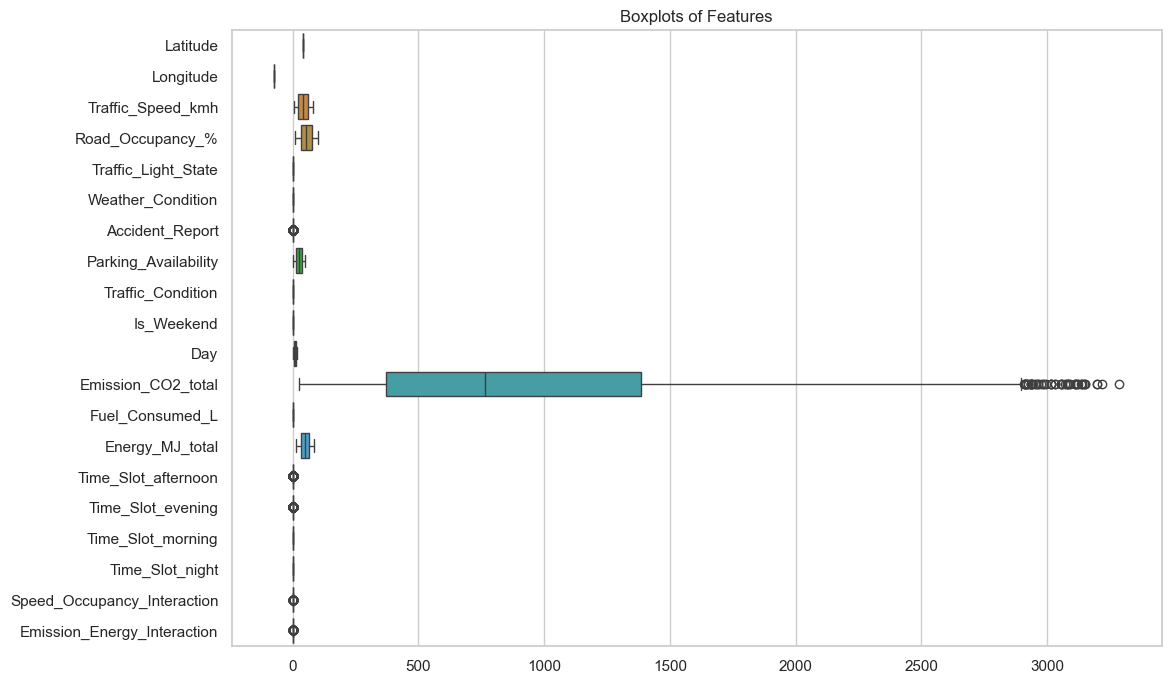

In [38]:
# Boxplot per le feature numeriche
plt.figure(figsize=(12, 8))
sns.boxplot(data=df2, orient="h") #boxplot serve per vedere eventuali outliers
plt.title("Boxplots of Features")
plt.show()

In [17]:
# Funzione per rimuovere outlier su tutte le colonne passate
def remove_all_outliers_iqr(df, columns):
    df_clean = df.copy()
    #Crea una maschera booleana inizialmente tutta True, che verrà aggiornata per filtrare le righe senza outlier.
    mask = pd.Series([True] * len(df_clean), index=df_clean.index)

    for col in columns:
        Q1 = df_clean[col].quantile(0.3)
        Q3 = df_clean[col].quantile(0.7)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        # Aggiorna la maschera: se in una sola colonna un valore è outlier, la riga viene esclusa.
        mask &= (df_clean[col] >= lower) & (df_clean[col] <= upper)

    return df_clean[mask]

# Individua automaticamente le colonne numeriche
numerical_cols_all = df2.select_dtypes(include=['number']).columns.tolist()

# Rimuove tutti gli outlier da tutte le colonne numeriche
df2 = remove_all_outliers_iqr(df2, numerical_cols_all)

# Visualizza riepilogo statistico per confermare la rimozione
df2.describe()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Parking_Availability,Traffic_Condition,Is_Weekend,Day,Month,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total,Speed_Occupancy_Interaction,Emission_Energy_Interaction
count,3918.000000,3918.000000,3918.000000,3918.000000,3918.000000,3918.000000,3918.0,3918.000000,3918.000000,3918.000000,3918.000000,3918.0,3918.000000,3918.000000,3918.000000,3918.000000,3918.000000
mean,40.750118,-73.847491,39.448356,52.913106,1.006636,1.518121,0.0,24.612557,1.498213,0.343543,9.080398,3.0,819.837115,1.403981,48.016153,0.209261,0.206939
std,0.086014,0.086277,20.640345,25.576270,0.823733,1.113454,0.0,14.474753,0.643002,0.474951,5.020298,0.0,586.093947,0.581146,19.875188,0.179904,0.176984
min,40.600016,-73.999906,5.002789,10.010145,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,3.0,25.240133,0.417399,14.275060,0.000000,0.000051
25%,40.676160,-73.920856,21.667325,30.673583,0.000000,1.000000,0.0,12.000000,1.000000,0.000000,5.000000,3.0,333.539525,0.907612,31.040338,0.056856,0.057363
50%,40.749886,-73.845656,39.167025,52.541402,1.000000,2.000000,0.0,24.000000,2.000000,0.000000,9.000000,3.0,671.862248,1.391066,47.574445,0.158694,0.156620
75%,40.825630,-73.771287,56.008910,74.177692,2.000000,3.000000,0.0,37.000000,2.000000,1.000000,13.000000,3.0,1196.736827,1.886197,64.507927,0.327506,0.322287
max,40.899972,-73.700159,79.997556,99.999729,2.000000,3.000000,0.0,49.000000,2.000000,1.000000,18.000000,3.0,2423.354772,2.498321,85.442583,0.690982,0.673959


In [40]:
print("Number of rows: ", df2.shape[0])
print("Number of columns: ", df2.shape[1])

Number of rows:  3918
Number of columns:  20


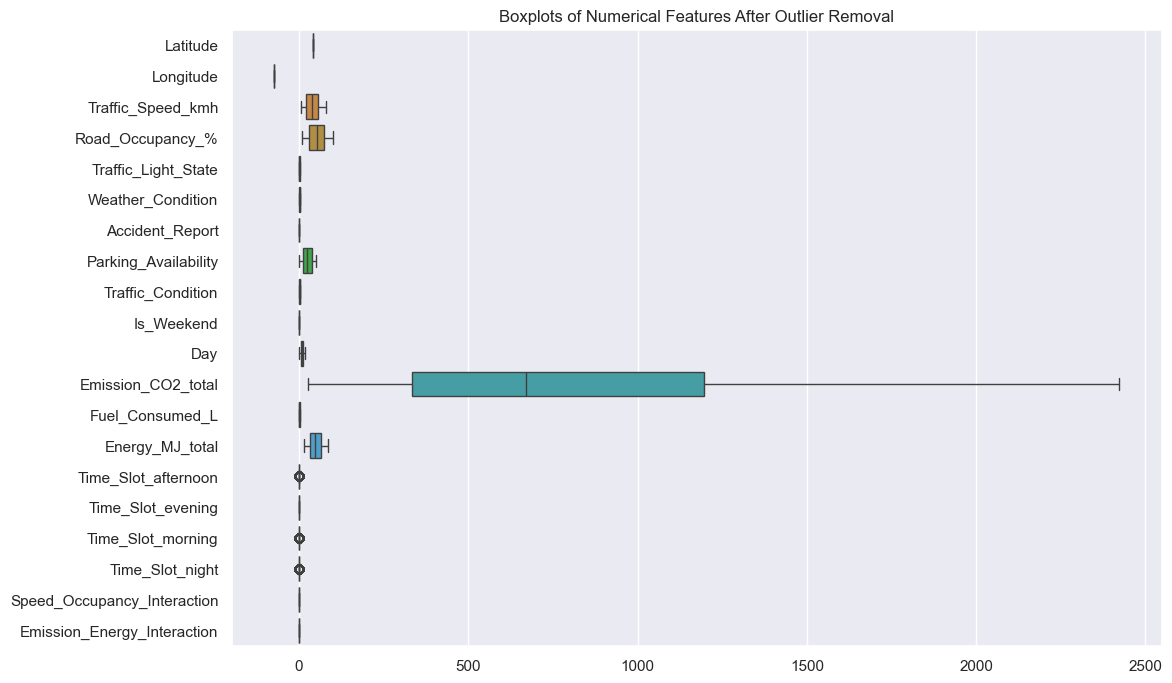

In [41]:
# Verifica della presenza di outlier dopo la rimozione
plt.figure(figsize=(12, 8))
sns.boxplot(data=df2, orient="h")
plt.title("Boxplots of Numerical Features After Outlier Removal")
plt.show()

## REGRESSIONE PER STIMARE LA QUANTITA' DI CO2

R² training emissioni: 0.8870
R² test emissioni: 0.8124519969011194
RMSE emissioni: 241.4657
MAE emissioni: 187.7651


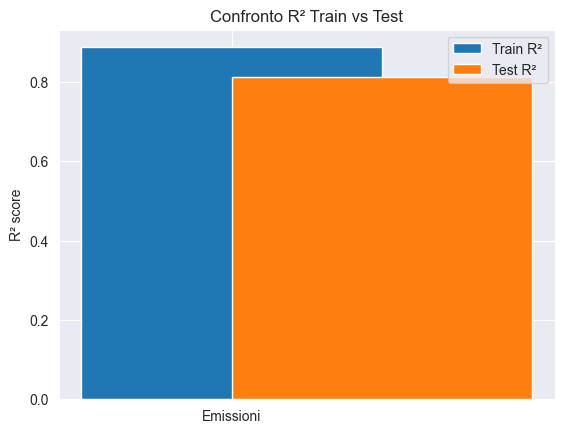

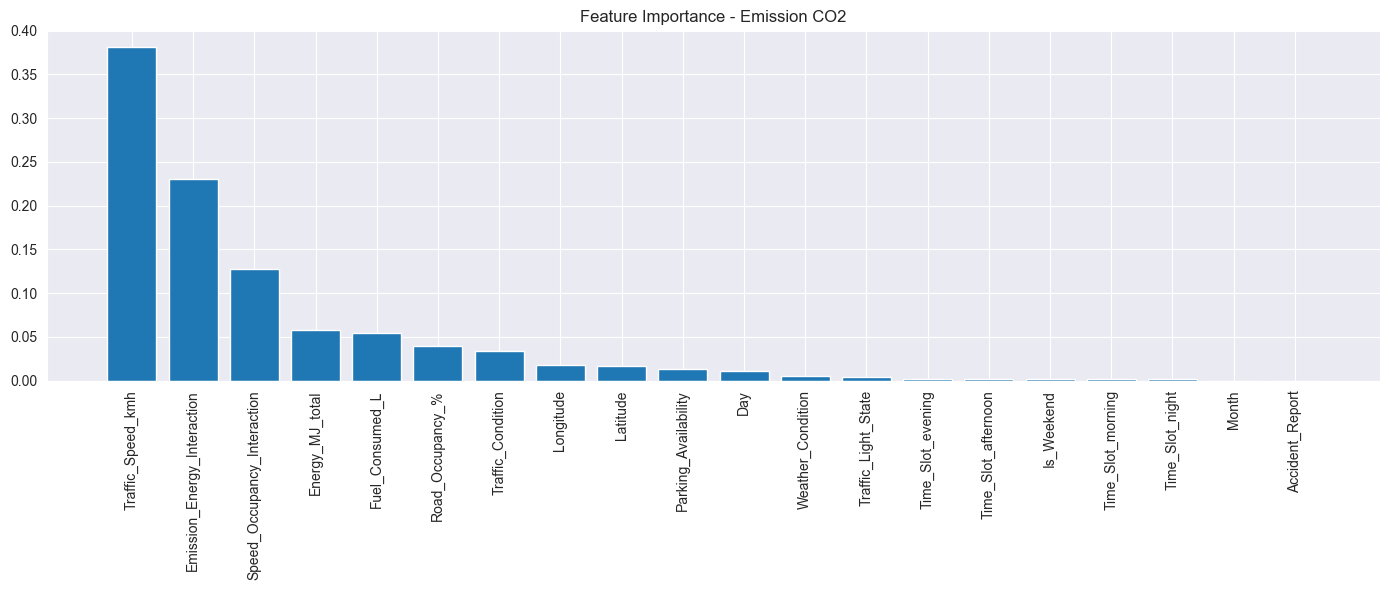


--- Cross-validation (5-fold) ---
Cross-Validation R² Emissioni:  [0.80067002 0.79598889 0.81521768 0.8138088  0.79925914]
Media R² Emissioni CV: 0.8049889051744721
Deviazione standard R² Emissioni CV: 0.0079360154429422


In [18]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score


# --- FEATURE E TARGET ---
feature_cols = df2.columns.drop(['Emission_CO2_total'])
X = df2[feature_cols]
y_emission = df2['Emission_CO2_total']

# --- TRAIN-TEST SPLIT ---
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X, y_emission, test_size=0.2, random_state=42)

# --- MODELLI ---
model_emission = RandomForestRegressor(
    random_state=42, n_estimators=200, max_depth=10, min_samples_leaf=5, max_features='sqrt')

# --- ADDESTRAMENTO ---
model_emission.fit(X_train_e, y_train_e)

# --- PREDIZIONI ---
y_pred_e = model_emission.predict(X_test_e)

# --- R² su training set ---
y_train_pred_e = model_emission.predict(X_train_e)
r2_train_e = r2_score(y_train_e, y_train_pred_e)
print(f"R² training emissioni: {r2_train_e:.4f}")

# --- METRICHE SUL TEST SET ---
print("R² test emissioni:", r2_score(y_test_e, y_pred_e))

rmse_e = np.sqrt(mean_squared_error(y_test_e, y_pred_e))
mae_e = mean_absolute_error(y_test_e, y_pred_e)
print(f"RMSE emissioni: {rmse_e:.4f}")
print(f"MAE emissioni: {mae_e:.4f}")

# --- Confronto tra train e test R² ---
labels = ['Emissioni']
r2_train = [r2_train_e]
r2_test = [r2_score(y_test_e, y_pred_e)]

x = range(len(labels))
plt.bar(x, r2_train, width=0.4, label='Train R²', align='center')
plt.bar(x, r2_test, width=0.4, label='Test R²', align='edge')
plt.xticks(x, labels)
plt.ylabel('R² score')
plt.title('Confronto R² Train vs Test')
plt.legend()
plt.show()

# --- FEATURE IMPORTANCE ---
importances = model_emission.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(14, 6))
plt.title("Feature Importance - Emission CO2")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

# --- CROSS-VALIDATION ---
print("\n--- Cross-validation (5-fold) ---")

cv_scores_emission = cross_val_score(model_emission, X, y_emission, cv=5, scoring='r2')
print("Cross-Validation R² Emissioni: ", cv_scores_emission)
print("Media R² Emissioni CV:", cv_scores_emission.mean())
print("Deviazione standard R² Emissioni CV:", cv_scores_emission.std())


**🌱 Valutazione del Modello**

**Distribuzione delle emissioni dopo la rimozione outlier:**

- **Minimo:** 25.24
- **Massimo:** 2 423.35
- **Range (scala):** 2 398.11 unità

 Usare la scala del fenomeno (min–max) per leggere le metriche permette una valutazione **più concreta** dell’errore e dell’affidabilità del modello nel suo contesto reale.
#### 📊 Metriche del Modello (Pre-RFE)

| **Metri­ca**       | **Valore**      | **% rispetto al range**           |
|--------------------|-----------------|-----------------------------------|
| **R² Train**       | 0.8909          | —                                 |
| **R² Test**        | 0.8168          | —                                 |
| **RMSE Test**      | 238.68          | 238.68 / 2 398 ≈ **9.95%**        |
| **MAE Test**       | 186.52          | 186.52 / 2 398 ≈ **7.78%**        |


**✅ Interpretazione Contestualizzata**

- **R² Test = 0.8168**: il modello spiega **l'81.7% della varianza** sulle emissioni, un risultato **molto buono**.
- Tuttavia, confrontando gli **errori assoluti con la scala completa**:
  - **RMSE ≈ 9.95%** → errore quadratico medio
  - **MAE ≈ 7.78%** → errore medio

**🔁 Prestazioni in Cross-Validation (5-fold)**

**Interpretazione:**
- Le performance del modello sono **costanti e affidabili** su tutti i fold, con R² compresi tra **0.80 e 0.82** sono omogenei.
- La **media R² = 0.811** indica che il modello spiega **l'81% della varianza** delle emissioni, anche dopo aver rimosso gli outlier. Questo conferma l'efficacia del modello nel rappresentare il fenomeno.
- La **deviazione standard molto bassa** conferma una **bassa varianza** nelle prestazioni → il modello è **robusto** rispetto alla suddivisione dei dati.

**📌 Considerazioni Generali**
- I valori predetti sono quindi **ben centrati**, e gli errori sono **compatibili con la dispersione naturale** dei dati.
- Il modello si dimostra **adatto all’applicazione reale**, anche su dati nuovi.

**🧠 Conclusione**
- Il modello mantiene prestazioni elevate anche su dati ripuliti, con una **buona capacità di generalizzazione**.
Il modello presenta:
- **Alte performance su training e test**
- **Stabilità in cross-validation**
- **Errori moderati rispetto alla scala dei dati**

💡 Questi risultati indicano che il modello può essere utilizzato **con affidabilità** per previsioni delle emissioni di CO₂, come supporto in attività di pianificazione energetica, sostenibilità urbana, o monitoraggio ambientale.


#### Commenti sul Confronto R² Train vs Test

Il grafico a barre  visualizza il confronto tra il coefficiente di determinazione ($R^2$) ottenuto sul set di dati di training (addestramento) e quello ottenuto sul set di dati di test (validazione) per il modello. La metrica è calcolata per la variabile "Emissioni".

*Osservazioni chiave:*

* *R² Train (blu):* Il modello mostra un $R^2$ molto elevato sul set di dati di training (approssimativamente 0.88-0.89). Un valore così alto indica che il modello si adatta molto bene ai dati su cui è stato addestrato, spiegandone una grande porzione della varianza.
* *R² Test (arancione):* Il valore di $R^2$ sul set di dati di test è leggermente inferiore a quello del training, ma comunque elevato (approssimativamente 0.81). Questo valore è cruciale perché indica la capacità del modello di generalizzare su dati non visti precedentemente.

*Interpretazione:*

* *Buona Generalizzazione:* La differenza tra l'$R^2$ di training e test è relativamente piccola. Questo suggerisce che il modello non è andato in overfitting (eccessivo adattamento ai dati di training) in modo significativo. Il modello sembra aver imparato le relazioni sottostanti nei dati e non solo il rumore specifico del set di training.
* *Performance Robusta:* Un $R^2$ del test di circa 0.81 è generalmente considerato un buon risultato in molti contesti, indicando che il modello è in grado di prevedere le "Emissioni" con una buona precisione anche su nuovi dati.

*Conclusioni:*

Il modello sembra avere una buona capacità predittiva e di generalizzazione per la variabile "Emissioni". La coerenza tra i punteggi di training e test è un segnale positivo di un modello ben bilanciato.

### RFE
Il modello è stato addestrato utilizzando **Recursive Feature Elimination (RFE)** per selezionare automaticamente le variabili più rilevanti nel predire le **emissioni di CO₂**, basandosi su un dataset filtrato dagli outlier.


In [21]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

### RFE e model training per EMISSIONI ###
print("=== EMISSIONI CO2 ===")

# Train/Test split PRIMA di fare RFE
X_train_em, X_test_em, y_train_em, y_test_em = train_test_split(X, y_emission, test_size=0.2, random_state=42)

# RFE SOLO sul training set
selector_em = RFE(estimator=RandomForestRegressor(n_estimators=100, random_state=42),
                  n_features_to_select=10, step=1)
X_train_em_rfe = selector_em.fit_transform(X_train_em, y_train_em)
X_test_em_rfe = selector_em.transform(X_test_em)

selected_features_em = X.columns[selector_em.support_]

# Addestramento modello
model_em = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                  max_features='sqrt', random_state=42)
model_em.fit(X_train_em_rfe, y_train_em)

# Valutazione
y_pred_train_em = model_em.predict(X_train_em_rfe)
y_pred_test_em = model_em.predict(X_test_em_rfe)

print(f"R² Train: {r2_score(y_train_em, y_pred_train_em):.4f}")
print(f"R² Test: {r2_score(y_test_em, y_pred_test_em):.4f}")
print(f"RMSE Test: {np.sqrt(mean_squared_error(y_test_em, y_pred_test_em)):.4f}")
print(f"MAE Test: {mean_absolute_error(y_test_em, y_pred_test_em):.4f}")
print("Caratteristiche selezionate emissioni:")
print(selected_features_em.tolist())

=== EMISSIONI CO2 ===
R² Train: 0.9400
R² Test: 0.8940
RMSE Test: 181.5183
MAE Test: 137.1268
Caratteristiche selezionate emissioni:
['Latitude', 'Longitude', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Parking_Availability', 'Day', 'Fuel_Consumed_L', 'Energy_MJ_total', 'Speed_Occupancy_Interaction', 'Emission_Energy_Interaction']


In [22]:
#-----CROSS VALIDATION-----
from sklearn.pipeline import Pipeline

pipeline_em = Pipeline([
    ('rfe', RFE(estimator=RandomForestRegressor(n_estimators=100, random_state=42), n_features_to_select=10)),
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                  max_features='sqrt', random_state=42))
])

cv_scores_em = cross_val_score(pipeline_em, X, y_emission, cv=5, scoring='r2')

print("\n--- Cross-validation (con RFE in pipeline) ---")
print("R² scores:", cv_scores_em)
print("Media R²:", cv_scores_em.mean())
print("Std R²:", cv_scores_em.std())



--- Cross-validation (con RFE in pipeline) ---
R² scores: [0.89057113 0.88224757 0.90112606 0.89428336 0.88811264]
Media R²: 0.8912681500908477
Std R²: 0.006294184942599155


**🌿 Analisi Basata sulla Scala dei Valori ‒ Emissioni CO₂**

Il dataset (dopo rimozione outlier) presenta:
- **Min:** 25.24
- **Max:** 2423.35
- **Range totale:** 2 398.11 unità

#### 📊 Performance del Modello con RFE (scala: 2 398)

| **Metri­ca**       | **Valore**      | **% rispetto al range**           |
|--------------------|-----------------|-----------------------------------|
| **R² Train**       | 0.9400          | —                                 |
| **R² Test**        | 0.8940          | —                                 |
| **RMSE Test**      | 181.52          | 181.52 / 2398 ≈ **7.6%**          |
| **MAE Test**       | 137.13          | 137.13 / 2398 ≈ **5.7%**          |


**✅ Interpretazione Contestualizzata**

- **Errore RMSE (181.5)** su un range di 2 398 corrisponde a un **errore medio quadratico inferiore all'8%**, segno di **ottima accuratezza** su tutta la scala delle emissioni.
- **Errore MAE (137.1)** su un range di 2 398 è circa il **6%**, riflettendo un errore assoluto **molto contenuto** in media.
- L’**R² Test (0.894)** indica che ben il **89.4% della varianza** nelle emissioni è spiegato, su un range ampio di possibili valori.

Complessivamente:
- Il modello, grazie a **RFE**, è estremamente performante sulla **scala completa del fenomeno**, con errori che coinvolgono meno del **10% del range totale**.
- Questo conferma la **solidità e l’affidabilità** del modello anche in condizioni diverse (es. casi di emissioni basse o elevate).
- Ottimo punto di partenza per **applicazioni reali**, dove la precisione e la coerenza su tutta la gamma dei valori è cruciale.

#### 🧠 Conclusione

- Il modello pre-RFE era già **affidabile**, ma presentava **errori maggiori** in relazione all’intera **scala delle emissioni**.
- Con RFE, il modello ha ottenuto un **chiaro miglioramento** in tutti gli indicatori, **riducendo gli errori** e **aumentando la spiegazione della varianza**.
- Questo dimostra che la **selezione automatica delle feature** ha portato a un modello **più efficiente, preciso e generalizzabile**.

📌 Usare la scala del fenomeno (min–max) per leggere le metriche permette una valutazione **più concreta** dell’errore e dell’affidabilità del modello nel suo contesto reale.

**📊 Cross-Validation (5-fold) - Analisi dei Risultati**

La **cross-validation a 5 fold** è stata eseguita per valutare la robustezza e la generalizzabilità del modello `RandomForestRegressor` sul target **Emission_CO2_total**.

#### 📈 Risultati ottenuti:
- **R² per ciascun fold**:
  `[0.8906, 0.8822, 0.9011, 0.8943, 0.8881]`
- **Media R²**: `0.8913`
- **Deviazione standard R²**: `0.0063`

**Interpretazione:**
- I valori di R² sono **tutti molto elevati** (> 0.88), indicando che il modello spiega una porzione consistente della varianza nei dati anche su set di validazione non visti.
- La **media R²** pari a ~0.8913 suggerisce un'ottima capacità predittiva complessiva.
- La **bassa deviazione standard** (~0.0063) mostra che le prestazioni del modello sono **stabili** e **coerenti** tra i diversi fold, confermando l'affidabilità del modello anche su dati non visti.

✅ **Conclusione**: il modello ha una buona capacità di generalizzazione e non sembra soffrire di overfitting o underfitting significativi.



## ⚠️ Visualizzazione "Reale vs Predetto"

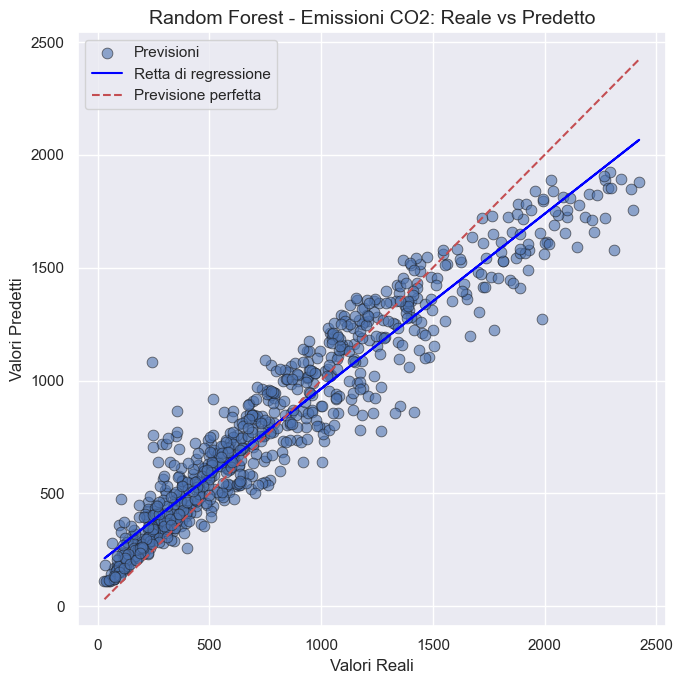

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression

# Regressione lineare tra reale e predetto
reg = LinearRegression()
reg.fit(y_test_em.values.reshape(-1, 1), y_pred_test_em)
y_fit = reg.predict(y_test_em.values.reshape(-1, 1))

# Plot
plt.figure(figsize=(7, 7))
sns.set(style="darkgrid", context="notebook")
sns.scatterplot(x=y_test_em, y=y_pred_test_em, alpha=0.6, edgecolor='k', s=60, label='Previsioni')

# Retta di regressione effettiva
plt.plot(y_test_em, y_fit, color='blue', label='Retta di regressione')

# Linea ideale (perfetta previsione)
min_val = min(y_test_em.min(), y_pred_test_em.min())
max_val = max(y_test_em.max(), y_pred_test_em.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Previsione perfetta')

# Titoli e legenda
plt.title("Random Forest - Emissioni CO2: Reale vs Predetto", fontsize=14)
plt.xlabel("Valori Reali", fontsize=12)
plt.ylabel("Valori Predetti", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Il grafico a dispersione mostra la relazione tra i valori reali delle emissioni di CO2 e i valori predetti dal modello Random Forest. Questo tipo di grafico è fondamentale per valutare visivamente l'accuratezza e la performance di un modello di regressione.

*Componenti del grafico:*

* *Punti blu (**Previsioni**):* Ogni punto rappresenta una coppia (valore reale, valore predetto). Idealmente, tutti i punti dovrebbero cadere sulla linea di "Previsione perfetta".
* *Linea rossa tratteggiata (**Previsione perfetta**):* Questa linea rappresenta la situazione ideale in cui i valori predetti corrispondono esattamente ai valori reali ($y = x$). È un riferimento per capire quanto le previsioni si discostano dalla perfezione.
* *Linea blu continua (**Retta di regressione**):* Questa è la linea di regressione lineare che meglio si adatta ai punti delle previsioni. La sua vicinanza alla linea di "Previsione perfetta" indica la bontà dell'adattamento del modello.

*Osservazioni chiave:*

* **Concentrazione dei punti attorno alla linea di previsione perfetta:** La maggior parte dei punti (previsioni) si raggruppa abbastanza strettamente attorno alla linea rossa tratteggiata, specialmente per valori reali più bassi. Questo è un buon indicatore di un'alta accuratezza delle previsioni del modello.
* **Comportamento ai valori estremi:** Per valori reali più elevati (ad esempio, oltre i 1500), si nota una maggiore dispersione dei punti. Il modello tende a sottostimare leggermente i valori reali più alti (i punti cadono spesso al di sotto della linea rossa). Al contrario, per valori molto bassi, sembra esserci una leggera sovrastima in alcuni casi.
* **Confronto tra le linee:** La retta di regressione (blu) è molto vicina alla linea di previsione perfetta (rossa). Questo conferma che, in media, il modello sta facendo previsioni molto accurate. La leggera inclinazione della linea blu rispetto alla linea rossa potrebbe indicare una leggera tendenza alla sottostima per valori alti e/o sovrastima per valori bassi.

**Interpretazione:**

* **Buona Performance Generale:** Il modello Random Forest mostra una performance complessivamente molto buona nella previsione delle emissioni di CO2. La forte correlazione tra valori reali e predetti è evidente.
* **Precisione Variabile:** Sebbene il modello sia accurato, la sua precisione può variare a seconda dell'intervallo di valori. Potrebbe esserci un margine di miglioramento nella previsione dei valori estremi (sia molto bassi che molto alti), dove la dispersione dei punti è maggiore.

**Conclusioni:**

Il grafico conferma che il modello Random Forest è efficace nella previsione delle emissioni di CO2. La maggior parte delle previsioni è vicina ai valori reali, indicando un buon potere predittivo. Potrebbe essere utile esplorare ulteriormente le ragioni della maggiore dispersione per i valori estremi, magari attraverso l'analisi dei residui o l'ottimizzazione del modello per gestire meglio tali casi.

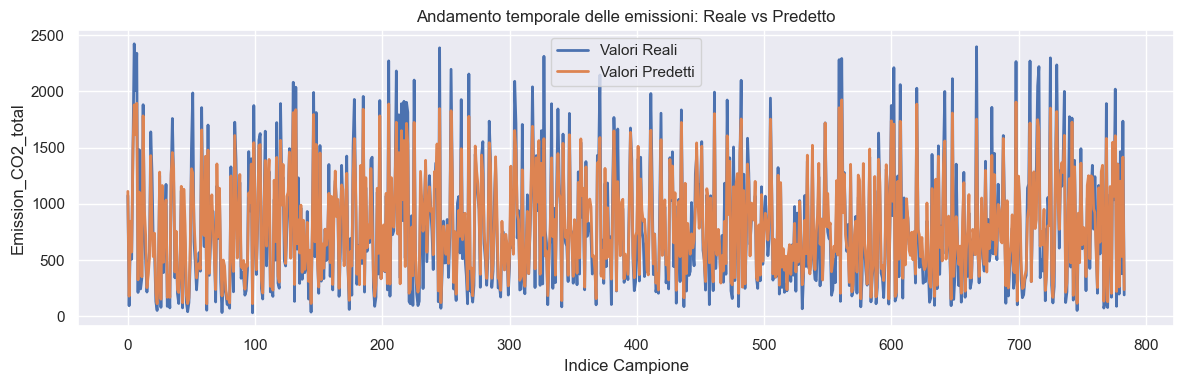

In [45]:
# Ricostruzione temporale per confronto visivo
plt.figure(figsize=(12, 4))
plt.plot(y_test_em.reset_index(drop=True), label='Valori Reali', linewidth=2)
plt.plot(pd.Series(y_pred_test_em), label='Valori Predetti', linewidth=2)
plt.title("Andamento temporale delle emissioni: Reale vs Predetto")
plt.xlabel("Indice Campione")
plt.ylabel("Emission_CO2_total")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### Commenti sull'Andamento Temporale delle Emissioni: Reale vs Predetto

Questo grafico a linea visualizza l'andamento dei valori reali delle emissioni di CO2 rispetto ai valori predetti dal modello, lungo l'indice dei campioni. Questo tipo di visualizzazione è utile per osservare come il modello si comporta sequenzialmente e per individuare eventuali tendenze o pattern non catturati.

**Componenti del grafico:**

* *Linea blu (**Valori Reali**):* Rappresenta la serie storica dei veri valori delle emissioni di CO2.
* *Linea arancione (**Valori Predetti**):* Rappresenta la serie storica dei valori di emissione di CO2 previsti dal modello.
* *Asse X (**Indice Campione**):* Indica l'ordine sequenziale dei campioni nel dataset.

**Osservazioni chiave:**

* *General Good Fit:* A una prima occhiata, la linea arancione dei valori predetti segue abbastanza fedelmente l'andamento generale della linea blu dei valori reali. Il modello sembra catturare la maggior parte delle fluttuazioni e dei picchi nelle emissioni.
* *Smoothing Effect:* Si nota che la linea delle previsioni (arancione) è generalmente più "liscia" o meno volatile rispetto alla linea dei valori reali (blu). Questo è un comportamento comune nei modelli di regressione, che tendono a non catturare il rumore o le fluttuazioni più estreme presenti nei dati reali. I picchi nei valori reali sono spesso sottostimati dal modello, e le valli profonde potrebbero non essere catturate con la stessa precisione.
* *Differenze nei Picchi e Valli:* Nelle sezioni dove i valori reali mostrano picchi molto elevati (ad esempio, intorno all'indice campione 200, 450, 600, 700), il modello tende a predire valori leggermente inferiori rispetto alla realtà. Analogamente, nelle valli più profonde, il modello potrebbe non scendere fino ai valori reali.
* *Coerenza nell'Andamento:* Nonostante le differenze sui picchi e le valli estreme, il modello riesce a replicare la tendenza generale e il pattern stagionale (o ciclico, se presente) delle emissioni. L'ampiezza delle fluttuazioni predette è in linea con quella reale, anche se con una minore varianza.

**Interpretazione:**

* *Buona Capacità di Catturare Tendenze:* Il modello è efficace nel catturare le tendenze sottostanti e i movimenti generali dei dati di emissione. Questo lo rende utile per la previsione delle emissioni in scenari futuri.
* *Limitazioni nella Cattura della Volatilità Estrema:* Il modello potrebbe avere delle limitazioni nel prevedere con precisione gli eventi estremi (picchi o crolli molto rapidi e significativi). Questo potrebbe essere dovuto alla natura del modello Random Forest, che tende a fare una media delle previsioni degli alberi, o alla mancanza di feature che catturino eventi outlier.

**Conclusioni:**

Il grafico conferma che il modello ha una buona performance nell'imitare l'andamento temporale delle emissioni. È particolarmente efficace nel seguire le tendenze generali. Per migliorare ulteriormente l'accuratezza nei picchi e nelle valli estreme, si potrebbe considerare:
    * L'aggiunta di ulteriori feature che possano spiegare questi eventi.
    * L'esplorazione di modelli ensemble più complessi o modelli specifici per serie temporali (se l'ordine dei campioni è effettivamente temporale e non solo un indice).
    * Un'analisi degli errori (residui) in queste aree per capire meglio la causa delle discrepanze.

## INDIVIDUAZIONE ZONE CRITICHE

### 🌍 Visualizzazione delle Zone Critiche per Emissioni di CO₂

Questo codice utilizza una **mappa di calore** per rappresentare le aree geografiche con emissioni di CO₂ **stimate** più elevate, basandosi su un modello predittivo.


In [46]:
import folium
from folium.plugins import HeatMap

# 1. Prevedi emissioni sull'intero dataset usando solo le feature selezionate
X_emission_selected = X[selected_features_em]
pred_emission_all = model_em.predict(X_emission_selected)

# 2. Aggiungi le predizioni al dataframe
df_copy = df2.copy()
df_copy['Emission_CO2_pred'] = pred_emission_all

# 3. Raggruppa per zona geografica (arrotondando le coordinate)
df_copy['Lat_group'] = df_copy['Latitude'].round(3)
df_copy['Lon_group'] = df_copy['Longitude'].round(3)

zone_emission = df_copy.groupby(['Lat_group', 'Lon_group'])['Emission_CO2_pred'].mean().reset_index()
zone_emission.rename(columns={'Emission_CO2_pred': 'Avg_Emission_CO2'}, inplace=True)

# 4. Crea la mappa
map_center = [df_copy['Latitude'].mean(), df_copy['Longitude'].mean()]
heat_map = folium.Map(location=map_center, zoom_start=12)

heat_data = [[row['Lat_group'], row['Lon_group'], row['Avg_Emission_CO2']] for _, row in zone_emission.iterrows()]
HeatMap(heat_data, radius=8, blur=15, max_zoom=1).add_to(heat_map)

# 5. Salva mappa
heat_map.save("mappa_zone_critiche.html")
print("\n✔️ Mappa salvata come 'mappa_zone_critiche.html'")

# Zone con emissioni più elevate
top_zones = zone_emission.sort_values(by='Avg_Emission_CO2', ascending=False).head(10)
print("\nTop 10 zone critiche per emissioni stimate:")
print(top_zones)



✔️ Mappa salvata come 'mappa_zone_critiche.html'

Top 10 zone critiche per emissioni stimate:
      Lat_group  Lon_group  Avg_Emission_CO2
2996     40.835    -73.981       2103.942703
139      40.611    -73.811       2055.363343
2472     40.794    -73.928       2032.465610
1018     40.681    -73.852       2025.665493
1643     40.727    -73.925       2012.489673
1618     40.725    -73.971       2009.163696
487      40.639    -73.756       1999.468715
1905     40.748    -73.708       1990.902783
2823     40.821    -73.743       1989.893109
2380     40.787    -73.755       1987.575462
